# Libs

In [412]:
import sys
sys.path.append('../..')

from importlib import reload
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import scipy.optimize as sci
import pickle
# %matplotlib notebook

# %config InlineBackend.figure_format='retina'

# Funcs

## Single resonator

### ABS (S21) Ustinov

$$S_{21} = a e^{i\alpha} e^{-2\pi i f \tau}\left[ 1 - \frac{Q_l/|Q_c|e^{i \varphi}}{1 + 2iQ_l(f/f_r - 1)}\right]$$           

$S_{21} =  1 - \frac{e^{i \varphi}Q_l/Q_e}{1 + 2iQ_l(f/f_r - 1)}$

In [419]:
def S21_funcUst_abs_Full(omega, omega_r, phi = 2 * np.pi, alpha = 1, a = 1, t = 1, Q_l = 1000, Q_c = 2000, dB = False): # (Hz, Hz, Hz)
    
    S_func = np.zeros_like(omega)
       

    S_func = alpha * np.exp(1j*a) * np.exp(-2*np.pi*1j*omega*t) * (1 - (np.exp(1j * phi) * Q_l/np.abs(Q_c))/(1 + 2 * 1j * Q_l * ((omega)/(omega_r) - 1) ))
    S_func = np.abs(S_func)**2
    if dB:
        S_func = 10 * np.log10(S_func) # DB
        
    return S_func # DB


In [421]:
def S21_funcUst_abs(omega, omega_r, kappa_r, Q_i = 1e5, phi = 2 * np.pi, dB = False): # (Hz, Hz, Hz)
    
    S_func = np.zeros_like(omega)
    
    Q_l = omega_r/(2 * kappa_r)
    Q_e = (1/Q_l - 1/Q_i)**(-1)
    

    S_func = np.abs(1 - (np.exp(1j * phi) * Q_l/Q_e)/(1 + 2 * 1j * Q_l * ( (omega)/(omega_r) - 1) ) )**2
    if dB:
        S_func = 10 * np.log10(S_func) # DB
        
    return S_func # DB


### Phase (S21) Ustinov

$S_{21} = arg\left(a e^{i\alpha} e^{-2\pi i f \tau}\left[ 1 - \frac{e^{i \varphi}Q_l/Q_e}{1 + 2iQ_l(f/f_r - 1)}\right]\right) + 2\pi f t + \phi_0$

$$S_{21} = arg\left(a e^{i\alpha} e^{-2\pi i f \tau}\left[ 1 - \frac{e^{i \varphi}Q_l/|Q_c|}{1 + 2iQ_l(f/f_r - 1)}\right]\right)$$

In [693]:
def S21_funcUst_phase_Full(omega, omega_r, phi = 2 * np.pi, alpha = 1, a = 1, t = 1, Q_l = 1000, Q_c = 2000): # (Hz, Hz, Hz)
    
    S_func = np.zeros_like(omega)
       

    S_func = alpha * np.exp(1j*a) * np.exp(-2*np.pi*1j*omega*t) * (1 - (np.exp(1j * phi) * Q_l/np.abs(Q_c))/(1 + 2 * 1j * Q_l * ((omega)/(omega_r) - 1) ))
    S_func = np.angle(S_func)
        
    return S_func 


In [724]:
def S21_funcUst_phase_Full_bias(omega, omega_r, phi = 2 * np.pi, alpha = 1, a = 1, t = 1, Q_l = 1000, Q_c = 2000, phi_0 = 0, shift = 1): # (Hz, Hz, Hz)
    
    S_func = np.zeros_like(omega)
       

    S_func = alpha * np.exp(1j*a) * np.exp(-2*np.pi*1j*omega*t) * (1 - (np.exp(1j * phi) * Q_l/np.abs(Q_c))/(1 + 2 * 1j * Q_l * ((omega)/(omega_r) - 1) ))
    S_func = np.angle(S_func) + 2 * np.pi * omega * shift + phi_0
        
    return S_func 


In [428]:
def S21_funcUst_phase(omega, omega_r, kappa_r, Q_i = 1e5, phi = 0, phi_0 = 0, t = 0, tau = 0, a = 1, alpha = 1): # (Hz, Hz, Hz)
    S_func = np.zeros_like(omega)
    
    Q_l = omega_r/(2 * kappa_r)
    Q_e = (1/Q_l - 1/Q_i)**(-1)
    
    for i in range(len(omega)):
        S_func[i] = np.angle( a * np.exp (1j * alpha) * np.exp (-2 * np.pi * 1j * omega[i] * tau) * (1 - (np.exp(1j * phi) * Q_l/Q_e)/(1 + 2 * 1j * Q_l * ( (omega[i])/(omega_r) - 1) )) )
        # S_func[i] = np.angle( ((Q_l/Q_e)/(1 + 2 * 1j * Q_l * ( (omega[i])/(omega_r) - 1) )) )
        S_func[i] += 2 * np.pi * omega[i] * t + phi_0
        
    return S_func


In [430]:
# S_21_theor = S21_funcUst_phase(omega_data, omega_r = 7.7e9, kappa_r = 2.2e6, Q_i = 13e3, phi_0 = 2148.14, t = -4.4e-08)
# # S_21_theor = np.unwrap(S_21_theor)
# plt.plot(omega_data, S_21_theor, label = "theor")

## Purcell plus resonator 

### Nakamura (S11) 

$S_{11} =  1 - \frac{ i  k_f  (\omega - \omega_c)}{(\omega - \omega_c)  (\omega - \omega_f + \frac{ik_f}{2}) - g_{cf}^2}$

In [435]:
def S11_Naka(omega, omega_r, omega_f, kappa_f, g_rf, dB = False): # (Hz, Hz, Hz)
    
    S_func = np.zeros_like(omega)
    
    for i in range(len(omega)):
        
        S_func[i] = np.abs(( 1 - 1j * kappa_f * (omega[i] - omega_r))/((omega[i] - omega_r) * (omega[i] - omega_f + ( 1j * kappa_f) / (2) ) - g_rf**2))**2
        S_func[i] = 1 - S_func[i]
        S_func[i] = np.sqrt(S_func[i])
        # S_func[i] = np.abs(  1j * kappa_f * (omega[i] - omega_r)/((omega[i] - omega_r) * (omega[i] - omega_f + 1j * kappa_f/2) - g_rf**2))
        if dB:
            S_func[i] = 10 * np.log(S_func[i]) # DB
        
    return S_func # DB


### Input-Output (S21)

$S_{21} =  1 - \frac{\kappa_P}{2}\frac{2i(\omega_d - \omega_R) + \gamma_R}{4J^2 + (2i(\omega_d - \omega_R) + \gamma_R)(2i(\omega_d - \omega_P) + \gamma_P + 2\kappa_P) }$

In [440]:
def S21_inout_PR(omega_d, omega_R, omega_P, kappa_P, J, dB = True, gamma_R = 0, gamma_P = 0): # (Hz, Hz, Hz)
    
    S_func = np.zeros_like(omega_d)
    
    for i in range(len(omega_d)):
        
        S_func[i] = np.abs(1 - kappa_P/2 * (2j * (omega_d[i] - omega_R) + gamma_R)/(4 * J**2 + (2j * (omega_d[i] - omega_R) + gamma_R) * (2j * (omega_d[i] - omega_P) + gamma_P + 2 * kappa_P )) )
        S_func[i] = S_func[i]**2
        if dB:
            S_func[i] = 10 * np.log(S_func[i]) # DB
        
    return S_func # DB


In [442]:
# omega_data = y1
# S_21_data = Abs_data_res[0]  # DB
# S_21_theor = S21_inout_PR(omega_d = omega_data, omega_R = 7.000e9, omega_P = 7.000e9, kappa_P = 40.691e6, J = 20.47e6, dB = True)
# Db = 36
# plt.plot(omega_data, 10 * np.log(S_21_data), label = "data")   # 10 ** np.log(S_21_data)
# plt.plot(omega_data, S_21_theor - Db, label = "theor")
# plt.legend()

### S21 (strange)

$S_{21} =  1 - \frac{k_f}{2} * 1/(2i\Delta_R + \gamma_R + 2\kappa_{eff})$

In [446]:
def S21_inout_single(omega, omega_r, kappa_f , kappa_eff, gamma_r = 0, dB = False): # (Hz, Hz, Hz)
    
    S_func = np.zeros_like(omega)
    
    for i in range(len(omega)):
        
        S_func[i] = np.abs( 1 - kappa_f/2 * 1/( 2j * (omega[i] - omega_r) + gamma_r + 2 * kappa_eff ) )**2
        
        # S_func[i] = np.abs(  1j * kappa_f * (omega[i] - omega_r)/((omega[i] - omega_r) * (omega[i] - omega_f + 1j * kappa_f/2) - g_rf**2))
        if dB:
            S_func[i] = 10 * np.log(S_func[i]) # DB
        
    return S_func # DB




## Bandwidth

$k_{eff} = \frac{1}{2}(k_f - Re(\sqrt{-16g_{rf}^2 + (k_f -2i\Delta_{rf})^2}))$

In [450]:
def K_eff_inout(omega_r, omega_f, kappa_f, g_rf): # (Hz, Hz, Hz, Hz)
    
    delta_rf = omega_r - omega_f
    K_eff = 1/2 * (kappa_f - np.real( np.sqrt(-16 * g_rf**2 + (kappa_f - 2j * delta_rf)**2)   ) )
        
    return K_eff 


In [452]:
# K_eff = K_eff_inout(5.735e9, 5.735e9, 3.0e6, 1e6)
# K_eff

$1/Q_l = 1/Q_i + 1/Q_e,\; Q = \omega/(2*\kappa_{qcreator})$

In [455]:
omega_Q = 6.65e+09
kappa_Q = 8.47e+06

phi = 2 * np.pi
Q_l = omega_Q/(2 * kappa_Q)
Q_i = 1e5
Q_e = (1/Q_l - 1/Q_i)**(-1)

Q_l, Q_e, Q_i

(392.56198347107437, 394.1091059946069, 100000.0)

# Выгрузка данных

## Link

In [953]:
# C:\\Users\\Professional\\Documents\\Romas_lib\\QCreator2\\designs\\Finger_quantim_capasitor\\Analisis\\Meash_purc_res\\2025-05-28\\
link1 = "C:\\Users\\Professional\\Documents\\Romas_lib\\FlipChip_Rustam\\Second_mesura_Oxford\\OneTone\\"
link2_data = "\\S-parameter\\data\\data.npy"
link2_y = "\\S-parameter\\parameters\\1\\data.npy"
link2_x = "\\S-parameter\\parameters\\0\\data.npy"

In [955]:
if 'Meas_dict' not in globals():
    # Meas_dict =  { 'meas_num':[],
    #             'type_of_meas':[],
    #             'data_params': []
    # }
    Meas_dict =  { 
    }
    print ('Meas_dict added')
else:
    print ('uzhe\n',Meas_dict)
typo =  { 'title': None,
            'subject': None,
            'type_of_meas': [],
            'data_params': {
                    
            } 
        }

uzhe
 {'101572': {'title': 'resonator_frequency-Flip_Chip_second', 'subject': '6 Res 2D data', 'type_of_meas': [], 'data_params': {}}, '101576': {'title': 'resonator_frequency-Flip_Chip_second', 'subject': '6 Res 2D data', 'type_of_meas': [], 'data_params': {}}}


## Data

In [1501]:
meas_num = "101576"
title = 'resonator_frequency-Flip_Chip_second'
subject = '6 Res'
 
data1 = np.load(link1 + f"{meas_num}-resonator_frequency-Flip_Chip_second.exdir" + link2_data)
                                                                                                      

try:
    y1 = np.load(link1 + f"{meas_num}-resonator_frequency-Flip_Chip_second.exdir" + link2_y)       #power
    x1 = np.load(link1 + f"{meas_num}-resonator_frequency-Flip_Chip_second.exdir" + link2_x)       #freq
    subject+=' 3D data'
    print("3D data")
except FileNotFoundError:
    y1 = [1]
    x1 = np.load(link1 + f"{meas_num}-resonator_frequency-Flip_Chip_second.exdir" + link2_x)       #freq
    subject+=' 2D data'
    print("2D data")

# 1r-1315 
# ABS omega_r = 5.7349e+09, kappa_r = 2.0815e+06, Db = 6.4985e+01, Qi = 6.4893e+05, Q = 1377.567222 
# Phase omega_r = 5.7349e+09, kappa_r = 1.9560e+06, Q_i = 5.2083e+05, phi_0 = 2.0620e+03, t = -5.7338e-08, Q = 1.4660e+03



2D data


In [1503]:
y1

[1]

In [1505]:
if not(f'{meas_num}' in Meas_dict):
    Meas_dict[f'{meas_num}'] = typo
    Meas_dict[f'{meas_num}']['title'] = title
    Meas_dict[f'{meas_num}']['subject'] = subject
    print(f'meas_num = {meas_num} added')
else:
    print('Error')
# data1.shape, data1, y1.shape, y1

Error


In [1507]:
Meas_dict

{'101572': {'title': 'resonator_frequency-Flip_Chip_second',
  'subject': '6 Res 2D data',
  'type_of_meas': [],
  'data_params': {}},
 '101576': {'title': 'resonator_frequency-Flip_Chip_second',
  'subject': '6 Res 2D data',
  'type_of_meas': [],
  'data_params': {}},
 '101574': {'title': 'resonator_frequency-Flip_Chip_second',
  'subject': '5 Res 2D data',
  'type_of_meas': [],
  'data_params': {}}}

In [1509]:
Data = []
for i in range(len(y1)):
    a = [0] * len(x1)
    Data.append(a)
for i in range(len(x1)):
    for j in range(len(y1)):
        if len(y1) == 1:
            Data[0][i] = data1[i]
        else:
            Data[j][i] = data1[j][i]

In [1511]:
Data[0][100:110]
x1[100:110]

array([6.639300e+09, 6.639322e+09, 6.639344e+09, 6.639366e+09,
       6.639388e+09, 6.639410e+09, 6.639432e+09, 6.639454e+09,
       6.639476e+09, 6.639498e+09])

## CSV

In [218]:
link = r'C:\Users\Professional\Documents\Romas_lib\FlipChip_Rustam\Files_simul\S21_X-mon_3D_res_tml_6Q_10mkm_500mhz.csv'
df = pd.read_csv(link, delimiter = ',')
S_data = df.values
# # S_data2 = df2.values
df.head()

df.columns
# # df.describe()
# df
# # sns.scatterplot(df, x = df['Freq [GHz]'], y = df['dB(S(2,1)) []'])

Index(['Freq [GHz]', 'dB(S(2,1)) []'], dtype='object')

In [220]:
# om = df['Freq [GHz]'][a_:b]
# om[a_+1]
df['dB(S(2,1)) []']
df['dB(S(2,1)) []'].shape
# omega_data.shape

(20001,)

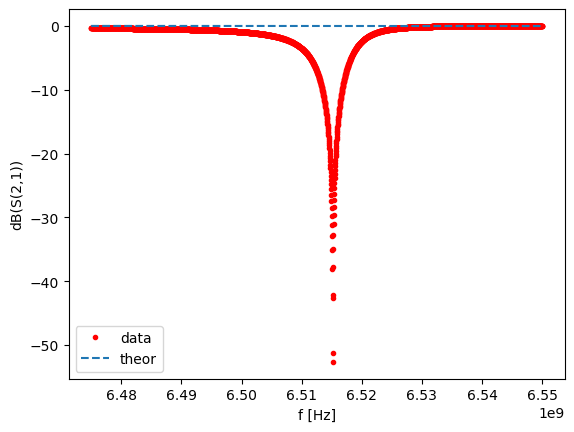

In [238]:
a_, b = 9000, 12000#0, len(df['Freq [GHz]'])#15000, 17000#
omega_data = (df['Freq [GHz]'][a_:b])*1e9 #np.linspace(y1[a], y1[b], int(1e6))#
data_CSV = df['dB(S(2,1)) []'][a_:b]  

S_21_data = (data_CSV) # abs
# S_21_data = (np.angle(data)) # phasa

S_21_theor = S21_funcUst_abs_Full(omega_data, omega_r= 6.590e+09, phi = 2 * np.pi, alpha = 1, a = 1, t = 1, Q_l = 1000, Q_c = 2000, dB = True) #abs
# S_21_theor = S21_funcUst_abs(omega_data, omega_r = 5.230e+09, kappa_r = 2.8874e+04, Q_i = 115509, dB = True)  #abs
# Db = 6.1808e+01 #abs

# S_21_theor = S21_funcUst_phase_Full(omega_data, omega_r= 5.230e+09, phi = 2 * np.pi, alpha = 1, a = 1, t = 1, Q_l = 1000, Q_c = 2000, dB = False)
# Db = 0 #phase

# plt.plot(omega_data, S_21_data, '.',label = "data", color = 'red') #phasa
# plt.plot(omega_data, S_21_theor, '.',label = "data", color = 'red') #phasa


plt.plot(omega_data, S_21_data, '.',label = "data", color = 'red') #abs 
# plt.plot(omega_data, 10 * np.log10(S_21_data), '-',label = "data", color = 'red') #abs dB
plt.plot(omega_data, S_21_theor, '--', label = "theor") # abs
plt.legend()
plt.xlabel('f [Hz]')  # Подпись для оси x  
plt.ylabel('dB(S(2,1))')
plt.show()

# First Look

## Abs

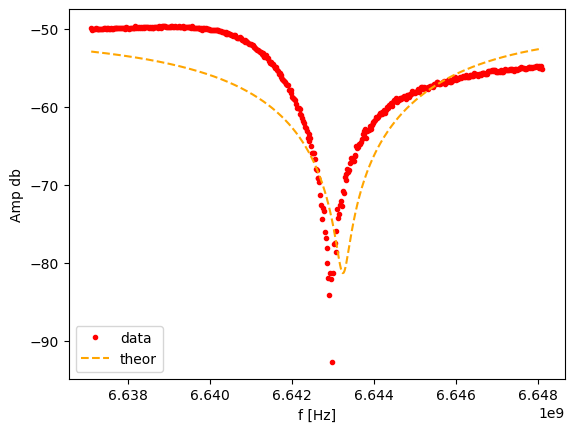

In [901]:
a, b = 0, len(x1)
omega_data = x1[a: b] 


S_21_data_abs = np.abs(Data[0][a: b])**2 
S_21_theor = S21_funcUst_abs_Full(omega_data, omega_r= 6.644e9, phi = 6.1346, alpha = 0.9861, a = 865169.6325, t = 2777985.6846, Q_l = 675.9036, Q_c = 650.3908, dB = True) #abs

dB = 50
plt.plot(omega_data, 10 * np.log10(S_21_data_abs), '.',label = "data", color = 'red') #abs
plt.plot(omega_data, S_21_theor - dB , '--', label = "theor", color = 'orange')
plt.legend()
plt.xlabel('f [Hz]') 
plt.ylabel('Amp db')
plt.show()

# plt.plot(omega_data, data_abs, '-',label = "data", color = 'black') #abs
# plt.plot(omega_data, theor_abs, '-', label = "theor", color = 'purple')
# plt.legend()
# plt.xlabel('f [Hz]') 
# plt.ylabel('Amp db')
# plt.show()

C:\Users\Professional\anaconda3\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\Professional\anaconda3\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


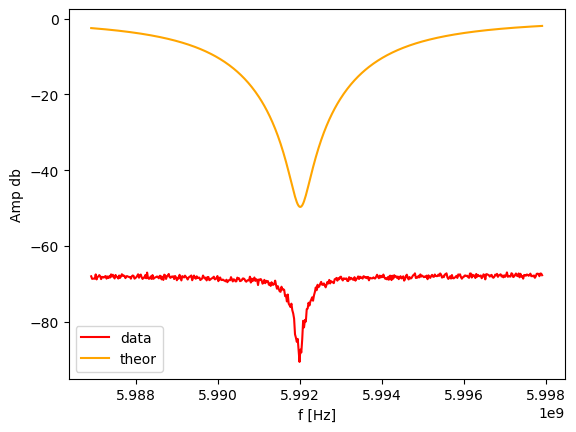

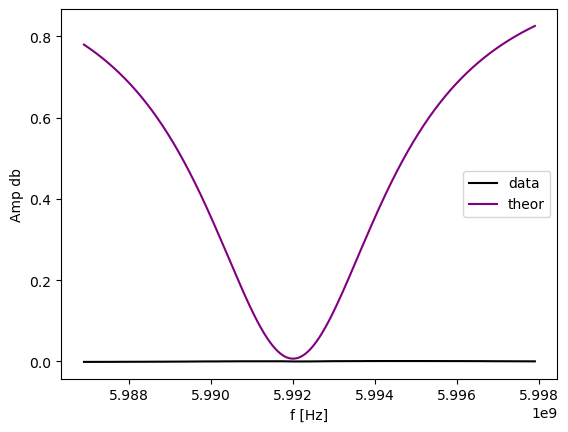

In [271]:
a, b = 0, len(x1)
omega_data = x1[a: b] 

data_abs = np.abs(Data[0][a: b])**2 
# theor_abs = S21_funcUst_abs(omega_data, omega_r = 5.992e+09, kappa_r = 1.3979e+04, Q_i = 5.8327e+05)
theor_abs = S21_funcUst_abs_Full(omega_data, omega_r = 5.992e+09, Q_l = 1e3+100, Q_e = 1e3+200)

Db = 140
plt.plot(omega_data, 10 * np.log(data_abs), '-',label = "data", color = 'red') #abs
plt.plot(omega_data, 10 * np.log(theor_abs) - Db, '-', label = "theor", color = 'orange')
plt.legend()
plt.xlabel('f [Hz]') 
plt.ylabel('Amp db')
plt.show()

plt.plot(omega_data, data_abs, '-',label = "data", color = 'black') #abs
plt.plot(omega_data, theor_abs, '-', label = "theor", color = 'purple')
plt.legend()
plt.xlabel('f [Hz]') 
plt.ylabel('Amp db')
plt.show()

## Phase

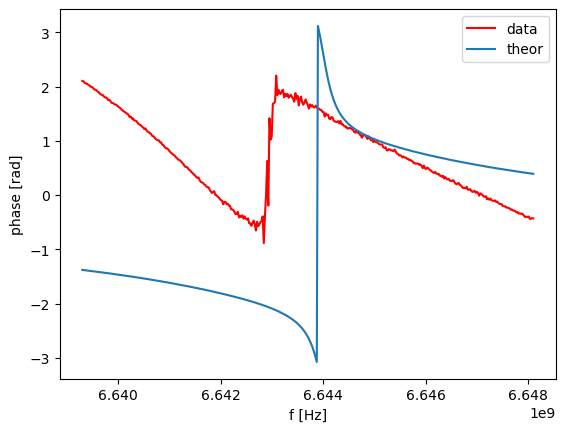

In [856]:
a, b = 100, len(x1)
omega_data = x1[a: b] 
data_ph = np.angle(Data[0][a: b]) # phasa
theor_ph = S21_funcUst_phase_Full(omega_data, omega_r= 6.644e9, phi = -2*np.pi, alpha = 0.9861, a = 1e2, t = 2e2, Q_l = 675.9036, Q_c = 650.3908) #abs
# theor_ph = S21_funcUst_phase_Full_bias(omega_data, omega_r= 6.644e9, phi = -2*np.pi, alpha = 0.9861, a = 1e2, t = 2e2, Q_l = 675.9036, Q_c = 650.3908, phi_0 = 1e-10, shift = 1e-10) #abs
# theor_ph = S21_funcUst_phase(omega_data, omega_r = 5.992e9, kappa_r = 1.3979e+04, 
#                                Q_i = 1.8327e+06, phi_0 = 3.5950e+00, t = -7.3929e-11) # phasa


plt.plot(omega_data, np.unwrap(data_ph), '-',label = "data", color = 'red') #phasa
plt.plot(omega_data, theor_ph, '-', label = "theor")
plt.legend()
plt.xlabel('f [Hz]')  # Подпись для оси x  
plt.ylabel('phase [rad]')
plt.show()

# Single Fit

## ABS Fit

### Ansys DATA

In [73]:
Fit_data_abs = data_abs
def fun(theta):
    return (S21_funcUst_abs(omega_data, omega_r = theta[0], kappa_r = theta[1], Q_i = theta[3], phi = theta[2], dB = True) - Fit_data_abs) ## если ансис то он сразу выдает в дб 
    # return (S21_funcUst_abs(omega_data, theta[0], theta[1], theta[3], dB = True) - theta[2] - 10 * np.log(Fit_data_abs))
    # return (S21_funcUst_abs(omega_data, theta[0], theta[1], theta[3], dB = False)[a_: b] - theta[2] - 10**(Fit_data_abs[a_:b]/10))

theta0 = [5.219e9, 2.0e6, np.pi, 1e5] 



res = sci.least_squares(fun, theta0, bounds=([0 * theta0[0], 0 * theta0[1], -2 * np.pi, 0 * theta0[3]], 
                                             [np.inf * theta0[0], np.inf * theta0[1], 2 * np.pi, np.inf * theta0[3]]), verbose = 2)
# res = sci.least_squares(fun, theta0, bounds=([5, 1], [7, 100]), verbose = 2)
res.x

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.9060e+02                                    2.23e+02    
       1              3         2.7448e+01      3.63e+02       4.12e+05       1.73e+03    
       2              4         9.7056e+00      1.77e+01       9.35e+03       1.18e+06    
       3              5         6.4457e+00      3.26e+00       1.02e+04       6.88e+02    
       4              6         4.8598e+00      1.59e+00       1.75e-01       6.24e+02    
`xtol` termination condition is satisfied.
Function evaluations 6, initial cost 3.9060e+02, final cost 4.8598e+00, first-order optimality 6.24e+02.


array([5.19040648e+09, 6.25902749e+00, 9.91021501e-01, 8.91904175e+03,
       6.20620116e+03, 2.20439524e+03, 2.14884198e+03])

In [723]:
Q = res.x[0]/(2 * res.x[1])
print(f'Q = {Q}')

Q = 2121.8371698342953


In [725]:
# theor_abs_0 = S21_funcUst_abs(omega_data, 5.992e9, 2.0e4, dB = True)
theor_abs = S21_funcUst_abs(omega_data, res.x[0], res.x[1], res.x[3], res.x[2], dB = True)

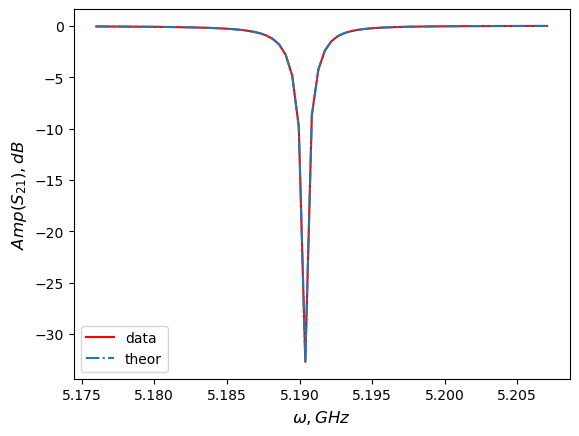

omega_r = 5.1904e+09, kappa_r = 1.2231e+06, phi = 6.2533e+00, Qi = 3.3261e+06, Q = 2.1218e+03


In [727]:
# dB = res.x[2]
a_ = 0
b = len(Fit_data_abs)
plt.plot(omega_data[a_:b]*1e-9, Fit_data_abs[a_:b], '-', label = "data", color = "red")
# plt.plot(omega_data[a_:b]*1e-9, 10 * np.log(Fit_data_abs), '-', label = "data", color = "red")
plt.plot(omega_data[a_:b]*1e-9, theor_abs[a_:b], '-.', label = "theor")
plt.xlabel(r'$\omega, GHz$', fontsize=12)  # Подпись для оси x  
plt.ylabel(r'$Amp(S_{21}), dB$', fontsize=12)
plt.legend()
# plt.grid()
# plt.axhline(y = -3)
# plt.axhline(y=-6, color='r', linestyle='--', label='Асимптота x = 0')
# plt.axvline(x = 6.06611010, color='r', linestyle='--', label='Асимптота x = 0')
# plt.savefig('S21_fing_cap_1_ansys.png')
plt.show()
print(f'omega_r = {res.x[0]:.4e}, kappa_r = {res.x[1]:.4e}, phi = {res.x[2]:.4e}, Qi = {res.x[3]:.4e}, Q = {Q:.4e}') 

### MESURA DATA

In [107]:
Fit_data_abs = data_abs
def fun(theta):
    return (S21_funcUst_abs(omega_data, theta[0], theta[1], theta[3], dB = True) - theta[2] - Fit_data_abs) ## если ансис то он сразу выдает в дб 
    # return (S21_funcUst_abs(omega_data, theta[0], theta[1], theta[3], dB = True) - theta[2] - 10 * np.log(Fit_data_abs))
    # return (S21_funcUst_abs(omega_data, theta[0], theta[1], theta[3], dB = False)[a_: b] - theta[2] - 10**(Fit_data_abs[a_:b]/10))

theta0 = [5.202e9, 2.0e6, 1e-10, 11559] 



res = sci.least_squares(fun, theta0, bounds=([0 * theta0[0], 0 * theta0[1], 0 * theta0[2], 0 * theta0[3]], 
                                             [np.inf * theta0[0], np.inf * theta0[1], np.inf * theta0[2], np.inf * theta0[3]]), verbose = 2)
# res = sci.least_squares(fun, theta0, bounds=([5, 1], [7, 100]), verbose = 2)
res.x

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.2255e+04                                    1.25e+04    
       1              2         3.7825e+03      8.47e+03       2.41e+05       4.57e+02    
       2              3         2.8297e+03      9.53e+02       4.73e+05       8.72e+06    
       3              4         2.7400e+03      8.98e+01       1.11e+05       1.72e+01    
       4              5         2.7241e+03      1.58e+01       3.81e+04       1.11e+06    
       5              6         2.7218e+03      2.34e+00       2.37e+04       4.67e+00    
       6              7         2.7214e+03      3.58e-01       6.92e+03       9.34e+04    
       7              8         2.7214e+03      5.61e-02       3.81e+03       3.47e+00    
       8              9         2.7214e+03      9.41e-03       1.29e+03       5.05e+03    
       9             10         2.7214e+03      1.58e-03       6.37e+02       7.33e-01    

array([5.20238539e+09, 2.41347432e+06, 6.10329073e-01, 5.10156562e+03])

In [109]:
Q = res.x[0]/(2 * res.x[1])
print(f'Q = {Q}')

Q = 1077.7793147276775


In [111]:
# theor_abs_0 = S21_funcUst_abs(omega_data, 5.992e9, 2.0e4, dB = True)
theor_abs = S21_funcUst_abs(omega_data, res.x[0], res.x[1], res.x[3], dB = True)

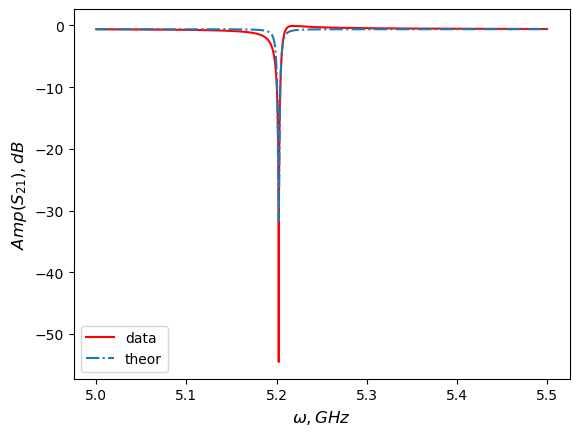

omega_r = 5.2024e+09, kappa_r = 2.4135e+06, dB = 6.1033e-01, Qi = 5.1016e+03, Q = 1.0778e+03


In [113]:
dB = res.x[2]
a_ = 0
b = len(Fit_data_abs)
plt.plot(omega_data[a_:b]*1e-9, Fit_data_abs, '-', label = "data", color = "red")
# plt.plot(omega_data[a_:b]*1e-9, 10 * np.log(Fit_data_abs), '-', label = "data", color = "red")
plt.plot(omega_data[a_:b]*1e-9, theor_abs[a_:b] - dB, '-.', label = "theor")
plt.xlabel(r'$\omega, GHz$', fontsize=12)  # Подпись для оси x  
plt.ylabel(r'$Amp(S_{21}), dB$', fontsize=12)
plt.legend()
# plt.grid()
# plt.axhline(y = -3)
# plt.axhline(y=-6, color='r', linestyle='--', label='Асимптота x = 0')
# plt.axvline(x = 6.06611010, color='r', linestyle='--', label='Асимптота x = 0')
# plt.savefig('S21_fing_cap_1_ansys.png')
plt.show()
print(f'omega_r = {res.x[0]:.4e}, kappa_r = {res.x[1]:.4e}, dB = {res.x[2]:.4e}, Qi = {res.x[3]:.4e}, Q = {Q:.4e}') 

In [111]:
typo2 = {'omega_r': [],
        'kappa_r': [],
        'dB': [],
        'Qi': [],
        'Q': [],
        'phi_0': [], 
        't': []}
sure = False

In [113]:
if sure:
    Meas_dict[f'{meas_num}']['type_of_meas'].append('ABS')
    Meas_dict[f'{meas_num}']['data_params'] = typo2
    Meas_dict[f'{meas_num}']['data_params']['omega_r'].append(res.x[0])
    Meas_dict[f'{meas_num}']['data_params']['kappa_r'].append(res.x[1])
    Meas_dict[f'{meas_num}']['data_params']['dB'].append(res.x[2] )
    Meas_dict[f'{meas_num}']['data_params']['Qi'].append(res.x[3] )
    Meas_dict[f'{meas_num}']['data_params']['Q'].append(Q)

In [115]:
# Meas_dict['101572']['type_of_meas'].pop()

In [117]:
Meas_dict

{'101572': {'title': 'resonator_frequency-Flip_Chip_second',
  'subject': '4 Res 2D data',
  'type_of_meas': ['ABS'],
  'data_params': {'omega_r': [5991980278.011942],
   'kappa_r': [442136.65605214913],
   'dB': [136.09325959497127],
   'Qi': [55068.58047797529],
   'Q': [6776.16320202277],
   'phi_0': [],
   't': []}}}

## Phase Fit

In [121]:
Fit_data_ph = data_ph

omega_r =  Meas_dict[f'{meas_num}']['data_params']['omega_r'][-1]
kappa_r =  Meas_dict[f'{meas_num}']['data_params']['kappa_r'][-1]
Q_i = Meas_dict[f'{meas_num}']['data_params']['Qi'][-1]

def fun1(theta):
    return (S21_funcUst_phase(omega_data, omega_r = omega_r, kappa_r = kappa_r, Q_i = Q_i, phi_0 = theta[0], t = theta[1]) - Fit_data_ph)

theta1 = [2.2791e+03, -5.9924e-08]

bounds_first1 = [ -1 * np.inf * theta1[0], np.inf * theta1[1]]
bounds_second1 = [np.inf * theta1[0], -1*np.inf * theta1[1]]

res_1 = sci.least_squares(fun1, theta1, bounds=(bounds_first1, bounds_second1), gtol=1e-15, verbose = 2)

print(f'phi_0 = {res_1.x[0]}, t = {res_1.x[1]}')

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.3431e+05                                    4.37e+14    
       1              2         3.4993e+02      1.34e+05       2.28e+03       3.54e+01    
       2              4         8.3780e+01      2.66e+02       1.14e+03       2.03e+01    
       3              6         1.9486e+01      6.43e+01       5.70e+02       1.05e+00    
       4              8         4.5350e+00      1.50e+01       2.85e+02       3.43e+00    
       5             10         1.3581e+00      3.18e+00       1.42e+02       9.74e-01    
       6             12         8.4436e-01      5.14e-01       7.12e+01       4.53e+00    
       7             15         8.3052e-01      1.38e-02       8.90e+00       1.62e+00    
       8             17         8.2780e-01      2.72e-03       4.45e+00       4.19e-01    
       9             19         8.2749e-01      3.11e-04       2.23e+00       2.15e-01    

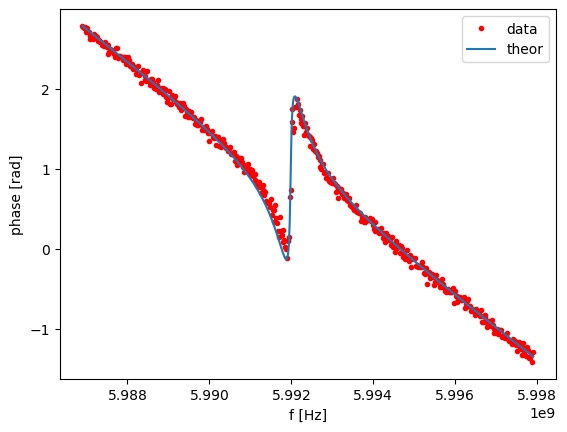

In [123]:
theor_ph = S21_funcUst_phase(omega_data, omega_r, kappa_r, phi_0 = res_1.x[0], t = res_1.x[1])
# theor_ph = np.unwrap(theor_ph)
plt.plot(omega_data, Fit_data_ph,  '.', label = "data", color = "red")
plt.plot(omega_data, theor_ph, label = "theor")
plt.xlabel('f [Hz]')  # Подпись для оси x  
plt.ylabel('phase [rad]')
plt.legend()
plt.show()

In [125]:

def fun2(theta):
    return (S21_funcUst_phase(omega_data, omega_r = theta[0], kappa_r = theta[1],  Q_i = theta[2], phi_0 = res_1.x[0], t = res_1.x[1]) - Fit_data_ph)

theta2 = [ omega_r,  kappa_r, Q_i]

bounds_first2 = [0 * theta2[0], 0 * theta2[1], 0 * theta2[2]]
bounds_second2 = [np.inf * theta2[0], np.inf * theta2[1], np.inf * theta2[2]]

res_2 = sci.least_squares(fun2, theta2, bounds=(bounds_first2, bounds_second2), gtol=1e-10, verbose = 2)

print(f'omega_R = {res_2.x[0]}, kappa_R = {res_2.x[1]}, Q_i = {res_2.x[2]}') 

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         8.2749e-01                                    1.18e+00    
       1              2         7.6491e-01      6.26e-02       3.49e+04       3.17e+03    
       2              3         7.6247e-01      2.44e-03       4.06e+03       2.35e+01    
       3              4         7.6244e-01      3.39e-05       5.04e+02       3.88e+01    
       4              5         7.6244e-01      2.72e-07       5.67e+01       7.30e-01    
`xtol` termination condition is satisfied.
Function evaluations 5, initial cost 8.2749e-01, final cost 7.6244e-01, first-order optimality 7.30e-01.
omega_R = 5991981290.471883, kappa_R = 405198.0794143037, Q_i = 67350.81811612754


In [127]:
Q = res_2.x[0]/(2 * res_2.x[1])
print(f'Q = {Q}')

Q = 7393.891524773553


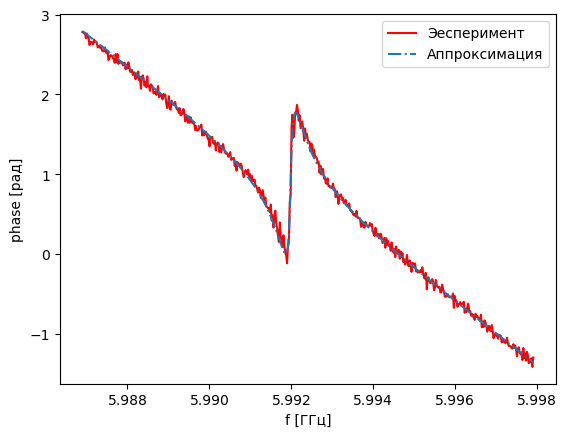

In [131]:
# a, b = 1100, 1300
theor_ph = S21_funcUst_phase(omega_data, res_2.x[0], res_2.x[1],  Q_i = res_2.x[2], phi_0 = res_1.x[0], t = res_1.x[1])

plt.plot(omega_data *1e-9, Fit_data_ph, '-', label = "Эесперимент", color = "red")
plt.plot(omega_data *1e-9, theor_ph, '-.', label = "Аппроксимация")
plt.xlabel('f [ГГц]')  # Подпись для оси x  
plt.ylabel('phase [рад]')

plt.legend()

In [133]:

def fun3(theta):
    return (S21_funcUst_phase(omega_data, res_2.x[0],  kappa_r = theta[0], Q_i = theta[1], phi_0 = res_1.x[0], t = res_1.x[1]) - Fit_data_ph)

theta3 = [ res_2.x[1], res_2.x[2]]

bounds_first3 = [0 * theta3[0], 0 * theta3[0]]
bounds_second3 = [np.inf * theta3[0], np.inf * theta3[0]]

res_3 = sci.least_squares(fun3, theta3, bounds=(bounds_first3, bounds_second3), gtol=1e-14, verbose = 2)

res_3.x

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         7.6244e-01                                    5.01e-05    
       1              2         7.6244e-01      2.65e-09       5.84e+00       5.62e-06    
`ftol` termination condition is satisfied.
Function evaluations 2, initial cost 7.6244e-01, final cost 7.6244e-01, first-order optimality 5.62e-06.


array([405193.23495504,  67354.08767639])

In [135]:
Q = res_2.x[0]/(2*res_3.x[0])
print(f'Q = {Q}')

Q = 7393.97992557388


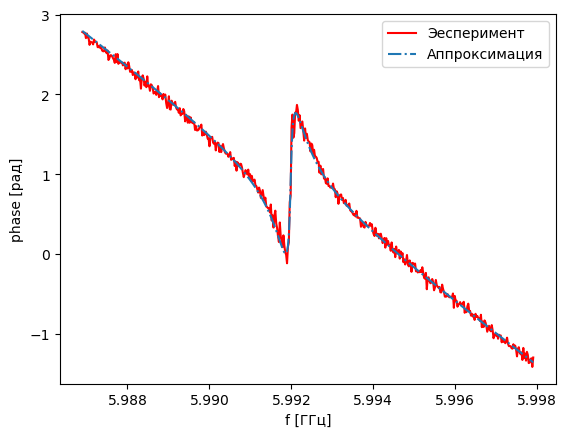

omega_r = 5.9920e+09, kappa_r = 4.0519e+05, Q_i = 6.7354e+04, phi_0 = 2.3349e+03, t = -6.2020e-08, Q = 7.3940e+03


In [137]:

theor_ph = S21_funcUst_phase(omega_data, res_2.x[0],  kappa_r = res_3.x[0], Q_i = res_3.x[1], phi_0 = res_1.x[0], t = res_1.x[1])
# theor_ph = np.unwrap(theor_ph)

plt.plot(omega_data *1e-9, Fit_data_ph, '-', label = "Эесперимент", color = "red")
plt.plot(omega_data *1e-9, theor_ph, '-.', label = "Аппроксимация")
plt.xlabel('f [ГГц]')  # Подпись для оси x  
plt.ylabel('phase [рад]')
plt.legend()
plt.show()
print(f'omega_r = {res_2.x[0]:.4e}, kappa_r = {res_3.x[0]:.4e}, Q_i = {res_3.x[1]:.4e}, phi_0 = {res_1.x[0]:.4e}, t = {res_1.x[1]:.4e}, Q = {Q:.4e}') 

In [149]:
sure_2 = False

In [151]:
if sure_2:
    Meas_dict[f'{meas_num}']['type_of_meas'].append('PH')
    Meas_dict[f'{meas_num}']['data_params']['omega_r'].append(res_2.x[0])
    Meas_dict[f'{meas_num}']['data_params']['kappa_r'].append(res_3.x[0])
    Meas_dict[f'{meas_num}']['data_params']['Qi'].append(res_3.x[1])
    Meas_dict[f'{meas_num}']['data_params']['phi_0'].append(res_1.x[0])
    Meas_dict[f'{meas_num}']['data_params']['t'].append(res_1.x[1])
    Meas_dict[f'{meas_num}']['data_params']['Q'].append(Q)
    

In [153]:
# Meas_dict['101572']['type_of_meas'].pop()

In [155]:
Meas_dict

{'101572': {'title': 'resonator_frequency-Flip_Chip_second',
  'subject': '4 Res 2D data',
  'type_of_meas': ['ABS', 'PH'],
  'data_params': {'omega_r': [5991980278.011942, 5991981290.471883],
   'kappa_r': [442136.65605214913, 405193.23495504475],
   'dB': [136.09325959497127],
   'Qi': [55068.58047797529, 67354.08767638839],
   'Q': [6776.16320202277, 7393.97992557388],
   'phi_0': [2334.8643502950663],
   't': [-6.202006781467179e-08]}}}

# update FIT

### MESYRA DATA

In [919]:
# Fit_data_abs = data_abs
Fit_data_abs = S_21_data_abs
def fun(theta):
    return (S21_funcUst_abs_Full(omega_data, omega_r = theta[0], phi = theta[1], alpha = theta[2], a = theta[3], t = theta[4], Q_l = theta[5], Q_c = theta[6], dB = False) 
            - Fit_data_abs  ) 
    # return (S21_funcUst_abs(omega_data, omega_r = theta[0], kappa_r = theta[1], Q_i = theta[3], phi = theta[2], dB = True) - Fit_data_abs) ## если ансис то он сразу выдает в дб 
    # return (S21_funcUst_abs(omega_data, theta[0], theta[1], theta[3], dB = True) - theta[2] - 10 * np.log(Fit_data_abs))
    # return (S21_funcUst_abs(omega_data, theta[0], theta[1], theta[3], dB = False)[a_: b] - theta[2] - 10**(Fit_data_abs[a_:b]/10))

theta0 = [6.64148704e+09, -5.63027300e+00,  4.15087324e+04,  5.49625668e+01,
        6.40599090e-08,  1.72847823e+03,  1.40356607e+03] 
# [6.642e9, 6.1346, 0.9861, 865169.6325, 2777985.6846, 675.9036, 650] 
# [6.64432196e+09, 6.28318531e+00, 3.16228189e+02, 3.24241396e+04,
#        1.86143505e+06, 1.18347015e+03, 5.91735509e+02]
# 6.5197e+09, phi = 5.8703, alpha = 0.9580, a = 0.0292, t = 0.0083, Q_l = 700.8720, Q_c = 595.6334
# 6.644e9, phi = 6.1346, alpha = 0.9861, a = 865169.6325, t = 2777985.6846, Q_l = 675.9036, Q_c = 650.3908

res = sci.least_squares(fun, theta0, bounds=([0 * theta0[0], -4 * np.pi, 0 * theta0[2], 0 * theta0[3], 0 * theta0[4], 0 * theta0[5], 0 * theta0[6]], 
                                             [np.inf * theta0[0], 4 * np.pi, np.inf * theta0[2], np.inf * theta0[3], np.inf * theta0[4], np.inf * theta0[5], np.inf * theta0[6]]), verbose = 2)
# res = sci.least_squares(fun, theta0, bounds=([5, 1], [7, 100]), verbose = 2)
res.x

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         6.3270e+20                                    8.36e+23    
       1              2         2.2820e+20      4.04e+20       1.07e+06       2.01e+23    
       2              3         4.1654e+19      1.87e+20       1.18e+06       1.67e+20    
       3              4         7.3664e+18      3.43e+19       1.63e+05       2.95e+19    
       4              5         1.2839e+18      6.08e+18       3.26e+05       5.25e+18    
       5              6         2.2262e+17      1.06e+18       6.52e+05       2.81e+18    
       6              7         3.7831e+16      1.85e+17       2.27e+05       7.02e+17    
       7              8         6.6145e+15      3.12e+16       1.52e+06       1.06e+17    
       8              9         1.1012e+15      5.51e+15       2.62e+06       1.18e+16    
       9             10         1.9225e+14      9.09e+14       5.22e+06       7.69e+14    

array([ 6.66031219e+09, -6.69775855e+00,  1.41449404e+03,  2.15204136e+07,
        2.13073750e+06,  8.35270400e+01,  7.60286165e+01])

In [921]:
# theor_abs_0 = S21_funcUst_abs(omega_data, 5.992e9, 2.0e4, dB = True)
theor_abs = S21_funcUst_abs_Full(omega_data, omega_r = res.x[0], phi = res.x[1], alpha = res.x[2], a = res.x[3], t = res.x[4], Q_l = res.x[5], Q_c = res.x[6], dB = False)

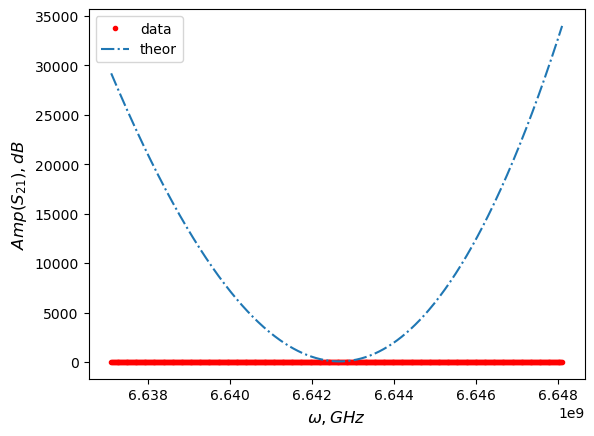

omega_r = 6.6603e+09, phi = -6.6978, alpha = 1414.4940, a = 21520413.6341, t = 2130737.5000, Q_l = 83.5270, Q_c = 76.0286


In [927]:

# plt.plot(omega_data, 10 * np.log10(Fit_data_abs), '.', label = "data", color = "red")
plt.plot(omega_data, Fit_data_abs, '.', label = "data", color = "red")

plt.plot(omega_data, theor_abs  , '-.', label = "theor")
plt.xlabel(r'$\omega, GHz$', fontsize=12)  # Подпись для оси x  
plt.ylabel(r'$Amp(S_{21}), dB$', fontsize=12)
plt.legend()
# plt.grid()
# plt.axhline(y = -3)
# plt.axhline(y=-6, color='r', linestyle='--', label='Асимптота x = 0')
# plt.axvline(x = 6.06611010, color='r', linestyle='--', label='Асимптота x = 0')
# plt.savefig('S21_fing_cap_1_ansys.png')
plt.show()
print(f'omega_r = {res.x[0]:.4e}, phi = {res.x[1]:.4f}, alpha = {res.x[2]:.4f}, a = {res.x[3]:.4f}, t = {res.x[4]:.4f}, Q_l = {res.x[5]:.4f}, Q_c = {res.x[6]:.4f}') 

In [588]:
kappaL = res.x[0]/(2 * res.x[5])
print(f'kappaL = {kappaL:.4e} Hz')

kappaL = 1.8778e+06 Hz


In [590]:
kappaC = res.x[0]/(2 * res.x[6])
print(f'kappaC = {kappaC:.4e} Hz')

kappaC = 2.4123e+06 Hz


## PHASE fit

In [893]:
S_21_data_phase = np.angle(Data[0][a: b]) 
Fit_data_phase = np.unwrap(S_21_data_phase)
def fun(theta):
    # return (S21_funcUst_phase_Full_bias(omega_data, omega_r = theta[0], phi = theta[1], alpha = theta[2], a = theta[3], t = theta[4], Q_l = theta[5], Q_c = theta[6], phi_0 = theta[7], shift = theta[8]) 
    #         - Fit_data_phase ) 
        return (S21_funcUst_phase_Full(omega_data, omega_r = theta[0], phi = theta[1], alpha = theta[2], a = theta[3], t = theta[4], Q_l = theta[5], Q_c = theta[6]) 
            - Fit_data_phase ) 


theta0 = [6.64148704e+09, -5.63027300e+00,  4.15087324e+04,  5.49625668e+01,
        6.40599090e-08,  1.72847823e+03,  1.40356607e+03] 

res = sci.least_squares(fun, theta0, bounds=([0 * theta0[0], -4 * np.pi, 0 * theta0[2], 0 * theta0[3], 0 * theta0[4], 0 * theta0[5], 0 * theta0[6]], 
                                             [np.inf * theta0[0], 4 * np.pi, np.inf * theta0[2], np.inf * theta0[3], np.inf * theta0[4], np.inf * theta0[5], np.inf * theta0[6]]), verbose = 2)

res.x

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.0213e+00                                    9.28e+02    
       1             16         2.0213e+00      0.00e+00       0.00e+00       9.28e+02    
`xtol` termination condition is satisfied.
Function evaluations 16, initial cost 2.0213e+00, final cost 2.0213e+00, first-order optimality 9.28e+02.


array([ 6.64148704e+09, -5.63027300e+00,  4.15087324e+04,  5.49625668e+01,
        6.40599090e-08,  1.72847823e+03,  1.40356607e+03])

In [895]:
# theor_abs_0 = S21_funcUst_abs(omega_data, 5.992e9, 2.0e4, dB = True)
theor_phase = S21_funcUst_phase_Full(omega_data, omega_r = res.x[0], phi = res.x[1], alpha = res.x[2], a = res.x[3], t = res.x[4], Q_l = res.x[5], Q_c = res.x[6])
# theor_phase = S21_funcUst_phase_Full_bias(omega_data, omega_r = res.x[0], phi = res.x[1], alpha = res.x[2], a = res.x[3], t = res.x[4], Q_l = res.x[5], Q_c = res.x[6], phi_0 = res.x[7], shift = res.x[8])

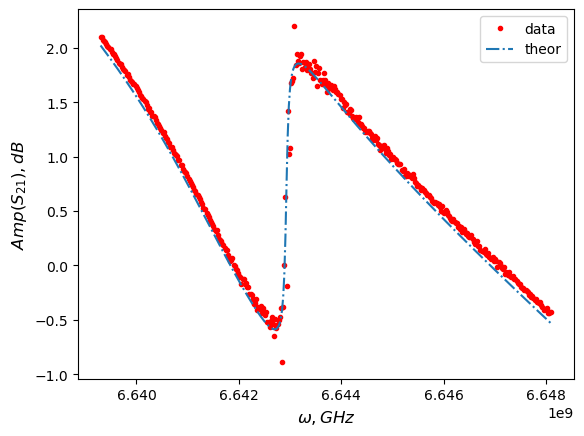

omega_r = 6.6415e+09, phi = -5.6303, alpha = 41508.7324, a = 54.9626, t = 0.0000, Q_l = 1728.4782, Q_c = 1403.5661


In [897]:

plt.plot(omega_data, Fit_data_phase, '.', label = "data", color = "red")

plt.plot(omega_data, theor_phase  , '-.', label = "theor")
plt.xlabel(r'$\omega, GHz$', fontsize=12)  # Подпись для оси x  
plt.ylabel(r'$Amp(S_{21}), dB$', fontsize=12)
plt.legend()
# plt.grid()
# plt.axhline(y = -3)
# plt.axhline(y=-6, color='r', linestyle='--', label='Асимптота x = 0')
# plt.axvline(x = 6.06611010, color='r', linestyle='--', label='Асимптота x = 0')
# plt.savefig('S21_fing_cap_1_ansys.png')
plt.show()
print(f'omega_r = {res.x[0]:.4e}, phi = {res.x[1]:.4f}, alpha = {res.x[2]:.4f}, a = {res.x[3]:.4f}, t = {res.x[4]:.4f}, Q_l = {res.x[5]:.4f}, Q_c = {res.x[6]:.4f}') 

## CSV DATA

In [240]:
# Fit_data_abs = data_abs
Fit_data_abs = data_CSV
def fun(theta):
    return (S21_funcUst_abs_Full(omega_data, omega_r = theta[0], phi = theta[1], alpha = theta[2], a = theta[3], t = theta[4], Q_l = theta[5], Q_c = theta[6], dB = True) 
            - Fit_data_abs) 
    # return (S21_funcUst_abs(omega_data, omega_r = theta[0], kappa_r = theta[1], Q_i = theta[3], phi = theta[2], dB = True) - Fit_data_abs) ## если ансис то он сразу выдает в дб 
    # return (S21_funcUst_abs(omega_data, theta[0], theta[1], theta[3], dB = True) - theta[2] - 10 * np.log(Fit_data_abs))
    # return (S21_funcUst_abs(omega_data, theta[0], theta[1], theta[3], dB = False)[a_: b] - theta[2] - 10**(Fit_data_abs[a_:b]/10))

theta0 = [6.5159e9, 6.1346, 0.9861, 865169.6325, 2777985.6846, 675.9036, 668.3908] 
# 6.5197e+09, phi = 5.8703, alpha = 0.9580, a = 0.0292, t = 0.0083, Q_l = 700.8720, Q_c = 595.6334
# 6.5159e+09, phi = 6.1346, alpha = 0.9861, a = 865169.6325, t = 2777985.6846, Q_l = 675.9036, Q_c = 668.3908

res = sci.least_squares(fun, theta0, bounds=([0 * theta0[0], -2 * np.pi, 0 * theta0[2], 0 * theta0[3], 0 * theta0[4], 0 * theta0[5], 0 * theta0[6]], 
                                             [np.inf * theta0[0], 2 * np.pi, np.inf * theta0[2], np.inf * theta0[3], np.inf * theta0[4], np.inf * theta0[5], np.inf * theta0[6]]), verbose = 2)
# res = sci.least_squares(fun, theta0, bounds=([5, 1], [7, 100]), verbose = 2)
res.x

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.3812e+02                                    1.66e+04    
       1              6         1.3812e+02      0.00e+00       0.00e+00       1.66e+04    
`xtol` termination condition is satisfied.
Function evaluations 6, initial cost 1.3812e+02, final cost 1.3812e+02, first-order optimality 1.66e+04.


array([6.51590000e+09, 6.13460000e+00, 9.86100000e-01, 8.65169632e+05,
       2.77798568e+06, 6.75903600e+02, 6.68390800e+02])

In [242]:
Q = res.x[0]/(2 * res.x[1])
print(f'Q = {Q}')

Q = 531077820.8848173


In [244]:
# theor_abs_0 = S21_funcUst_abs(omega_data, 5.992e9, 2.0e4, dB = True)
theor_abs = S21_funcUst_abs_Full(omega_data, omega_r = res.x[0], phi = res.x[1], alpha = res.x[2], a = res.x[3], t = res.x[4], Q_l = res.x[5], Q_c = res.x[6], dB = True)

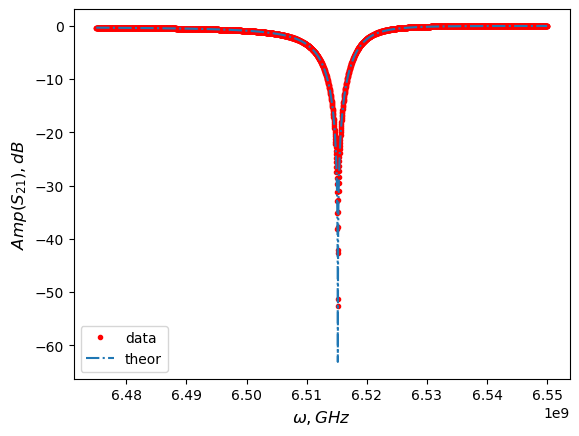

omega_r = 6.5159e+09, phi = 6.1346, alpha = 0.9861, a = 865169.6325, t = 2777985.6846, Q_l = 675.9036, Q_c = 668.3908


In [246]:

plt.plot(omega_data, Fit_data_abs, '.', label = "data", color = "red")

plt.plot(omega_data, theor_abs, '-.', label = "theor")
plt.xlabel(r'$\omega, GHz$', fontsize=12)  # Подпись для оси x  
plt.ylabel(r'$Amp(S_{21}), dB$', fontsize=12)
plt.legend()
# plt.grid()
# plt.axhline(y = -3)
# plt.axhline(y=-6, color='r', linestyle='--', label='Асимптота x = 0')
# plt.axvline(x = 6.06611010, color='r', linestyle='--', label='Асимптота x = 0')
# plt.savefig('S21_fing_cap_1_ansys.png')
plt.show()
print(f'omega_r = {res.x[0]:.4e}, phi = {res.x[1]:.4f}, alpha = {res.x[2]:.4f}, a = {res.x[3]:.4f}, t = {res.x[4]:.4f}, Q_l = {res.x[5]:.4f}, Q_c = {res.x[6]:.4f}') 

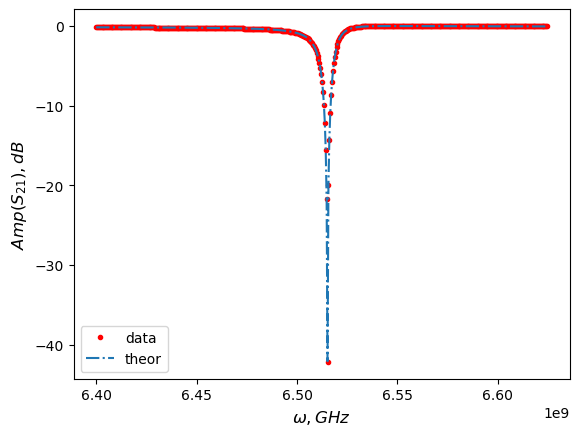

omega_r = 6.5159e+09, phi = 6.1346, alpha = 0.9861, a = 865169.6325, t = 2777985.6846, Q_l = 675.9036, Q_c = 668.3908


In [206]:

plt.plot(omega_data, Fit_data_abs, '.', label = "data", color = "red")

plt.plot(omega_data, theor_abs, '-.', label = "theor")
plt.xlabel(r'$\omega, GHz$', fontsize=12)  # Подпись для оси x  
plt.ylabel(r'$Amp(S_{21}), dB$', fontsize=12)
plt.legend()
# plt.grid()
# plt.axhline(y = -3)
# plt.axhline(y=-6, color='r', linestyle='--', label='Асимптота x = 0')
# plt.axvline(x = 6.06611010, color='r', linestyle='--', label='Асимптота x = 0')
# plt.savefig('S21_fing_cap_1_ansys.png')
plt.show()
print(f'omega_r = {res.x[0]:.4e}, phi = {res.x[1]:.4f}, alpha = {res.x[2]:.4f}, a = {res.x[3]:.4f}, t = {res.x[4]:.4f}, Q_l = {res.x[5]:.4f}, Q_c = {res.x[6]:.4f}') 

In [1746]:
x1

array([6.637100e+09, 6.637122e+09, 6.637144e+09, 6.637166e+09,
       6.637188e+09, 6.637210e+09, 6.637232e+09, 6.637254e+09,
       6.637276e+09, 6.637298e+09, 6.637320e+09, 6.637342e+09,
       6.637364e+09, 6.637386e+09, 6.637408e+09, 6.637430e+09,
       6.637452e+09, 6.637474e+09, 6.637496e+09, 6.637518e+09,
       6.637540e+09, 6.637562e+09, 6.637584e+09, 6.637606e+09,
       6.637628e+09, 6.637650e+09, 6.637672e+09, 6.637694e+09,
       6.637716e+09, 6.637738e+09, 6.637760e+09, 6.637782e+09,
       6.637804e+09, 6.637826e+09, 6.637848e+09, 6.637870e+09,
       6.637892e+09, 6.637914e+09, 6.637936e+09, 6.637958e+09,
       6.637980e+09, 6.638002e+09, 6.638024e+09, 6.638046e+09,
       6.638068e+09, 6.638090e+09, 6.638112e+09, 6.638134e+09,
       6.638156e+09, 6.638178e+09, 6.638200e+09, 6.638222e+09,
       6.638244e+09, 6.638266e+09, 6.638288e+09, 6.638310e+09,
       6.638332e+09, 6.638354e+09, 6.638376e+09, 6.638398e+09,
       6.638420e+09, 6.638442e+09, 6.638464e+09, 6.6384

In [1750]:
Data

[[(-0.0031673023477196693-0.00047961174277588725j),
  (-0.0030880419071763754-0.0004731765075121075j),
  (-0.0031136940233409405-0.00040456195711158216j),
  (-0.0031508442480117083-0.0003654978354461491j),
  (-0.0031431338284164667-0.0003826453466899693j),
  (-0.0031809923239052296-0.00029724888736382127j),
  (-0.0031638718210160732-0.0002742422802839428j),
  (-0.003163202665746212-0.0002096250100294128j),
  (-0.003154766047373414-0.0002247006632387638j),
  (-0.003136837389320135-0.00018202343198936433j),
  (-0.003163680201396346-7.077977352309972e-05j),
  (-0.0031711403280496597-0.0001285027974518016j),
  (-0.0031436015851795673-6.759120878996328e-05j),
  (-0.0031602077651768923-5.653009066008963e-05j),
  (-0.0032232613302767277-1.568233892612625e-05j),
  (-0.003208812791854143+3.768537862924859e-05j),
  (-0.0031528049148619175+6.814531661802903e-05j),
  (-0.003153800033032894+8.312078716699034e-05j),
  (-0.0032054821494966745+0.0001079425128409639j),
  (-0.003205321729183197+0.000172

# New FIT


$$S_{21} = a e^{i\alpha} e^{-2\pi i f \tau}\left[ 1 - \frac{Q_l/|Q_c|e^{i \varphi}}{1 + 2iQ_l(f/f_r - 1)}\right]$$           

$$ABS\;S_{21} = |a e^{i\alpha} e^{-2\pi i f \tau}\left[ 1 - \frac{Q_l/|Q_c|e^{i \varphi}}{1 + 2iQ_l(f/f_r - 1)}\right]|^{2}$$  

$$Phase\;S_{21} = arg\left(a e^{i\alpha} e^{-2\pi i f \tau}\left[ 1 - \frac{e^{i \varphi}Q_l/|Q_c|}{1 + 2iQ_l(f/f_r - 1)}\right]\right)$$

In [1757]:
def S21_funcUst_Full(omega, omega_r, phi = 2 * np.pi, a = 1, alpha = 1, t = 1, Q_l = 1000, Q_c = 2000): 
    
    S_func = np.zeros_like(omega)
    S_func = a * np.exp(1j*alpha) * np.exp(-2*np.pi*1j*omega*t) * (1 - (np.exp(1j * phi) * Q_l/np.abs(Q_c))/(1 + 2 * 1j * Q_l * ((omega)/(omega_r) - 1) ))
   
    return S_func


## SHOW Circule

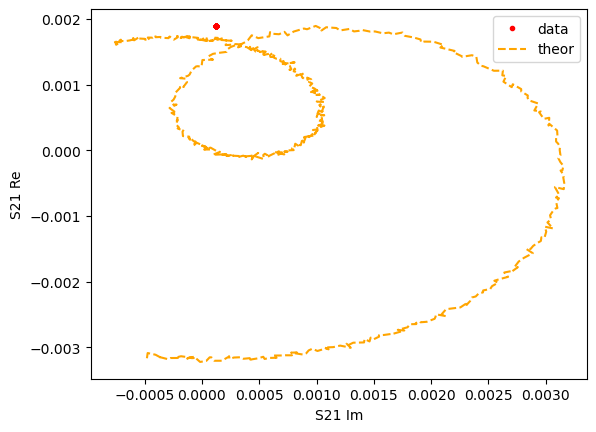

In [1760]:
a, b = 0, len(x1)
omega_data = x1[a: b] 

S_21_data_Im = np.imag(Data[0][a: b])
S_21_data_Re = np.real(Data[0][a: b])

S_21_theor = S21_funcUst_Full(omega_data, omega_r = 6.2444e+09, phi = 0.6243, alpha = -6.2207, a = 0.0019, t = 0.0000, Q_l = 1867.7085, Q_c = 1548.4475) 

S_21_theor_Im = np.imag(S_21_theor)
S_21_theor_Re = np.real(S_21_theor)


plt.plot(S_21_theor_Im, S_21_theor_Re, '.',label = "data", color = 'red') #abs
plt.plot(S_21_data_Im, S_21_data_Re , '--', label = "theor", color = 'orange')


plt.legend()
plt.xlabel('S21 Im') 
plt.ylabel('S21 Re')
plt.show()



## SHOW ABS

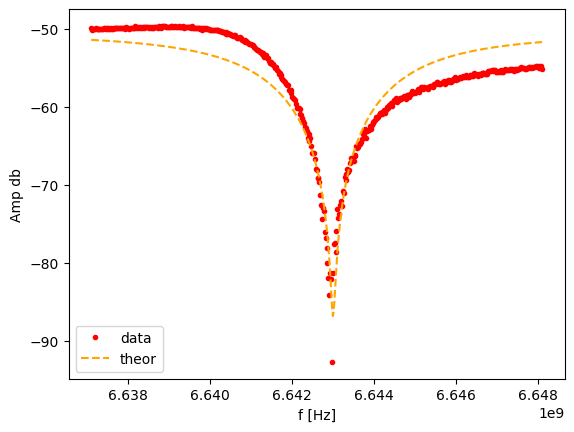

In [1763]:
a, b = 0, len(x1)
omega_data = x1[a: b] 

S_21_data_abs = np.abs(Data[0][a: b])**2 

S_21_theor = S21_funcUst_abs_Full(omega_data, omega_r = 6.6430e+09, phi = 0.0000, alpha = 0.0000, a = 0.0030, t = 0.0000, Q_l = 1139.3691, Q_c = 1156.8270) 

S_21_theor_abs = np.abs(S_21_theor)**2 

dB = 50
plt.plot(omega_data, 10*np.log10(S_21_data_abs), '.',label = "data", color = 'red') #abs
plt.plot(omega_data, 10*np.log10(S_21_theor_abs) , '--', label = "theor", color = 'orange')


plt.legend()
plt.xlabel('f [Hz]') 
plt.ylabel('Amp db')
plt.show()



### ABS FIT

In [1766]:
Fit_data_abs = np.abs(Data[0][a: b])**2 

def fun(theta):
    theor_curve = S21_funcUst_Full(omega_data, omega_r = theta[0], phi = theta[1], alpha = theta[2], a = theta[3], t = theta[4], Q_l = theta[5], Q_c = theta[6])
    theor_curve = np.abs(theor_curve)**2
    data_curve = Fit_data_abs 
    # return ( 10 * np.log10(theor_curve) - 10 * np.log10(data_curve) ) 
    return ( theor_curve - data_curve ) 

theta0 = [6.64261553e+09, 1.57439323e-13, 1.40315330e-13, 1.00000000e-01,
       3.19660743e-07, 1.84763296e+02, 1.76780083e+02] 


res = sci.least_squares(fun, theta0, bounds=([6.64e9,      0,      0,  0.1,     0, 1e2, 1e2], 
                                             [6.65e9,  1e-12,  1e-12,   10, 1e-6, 1e5, 1e5]), verbose = 2)
# res = sci.least_squares(fun, theta0, bounds=([6.23e9, -2 * np.pi, -2 * np.pi,  0,    0, 1e2, 1e2], 
#                                              [6.25e9,  2 * np.pi,  2 * np.pi,  1, 1e-6, 1e5, 1e5]), verbose = 2)
res.x

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.0900e-05                                    7.90e-02    
       1              3         4.0900e-05      0.00e+00       0.00e+00       7.90e-02    
`xtol` termination condition is satisfied.
Function evaluations 3, initial cost 4.0900e-05, final cost 4.0900e-05, first-order optimality 7.90e-02.


array([6.64261553e+09, 5.00000000e-13, 5.00000000e-13, 1.00000000e-01,
       3.19660743e-07, 1.84763296e+02, 1.76780083e+02])

In [1768]:
# theor_abs_0 = S21_funcUst_abs(omega_data, 5.992e9, 2.0e4, dB = True)
theor_abs = S21_funcUst_Full(omega_data, omega_r = res.x[0], phi = res.x[1], alpha = res.x[2], a = res.x[3], t = res.x[4], Q_l = res.x[5], Q_c = res.x[6])

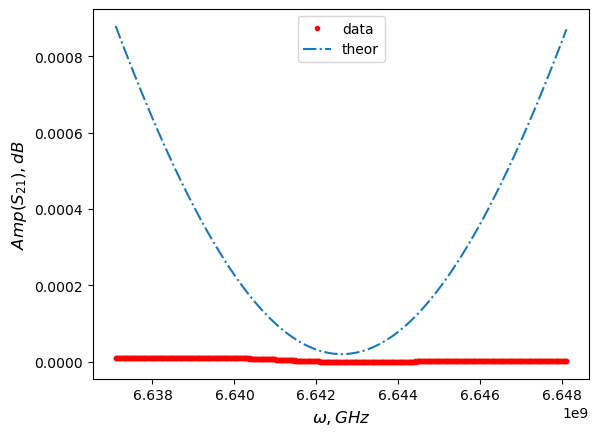

omega_r = 6.6426e+09, phi = 0.0000, alpha = 0.0000, a = 0.1000, t = 0.0000, Q_l = 184.7633, Q_c = 176.7801


In [1770]:
theor_abs = np.abs(theor_abs)**2


# plt.plot(omega_data, 10 * np.log10(Fit_data_abs), '.', label = "data", color = "red")
# plt.plot(omega_data, 10 * np.log10(theor_abs)  , '-.', label = "theor")

plt.plot(omega_data, Fit_data_abs, '.', label = "data", color = "red")
plt.plot(omega_data, theor_abs, '-.', label = "theor")

plt.xlabel(r'$\omega, GHz$', fontsize=12)  # Подпись для оси x  
plt.ylabel(r'$Amp(S_{21}), dB$', fontsize=12)
plt.legend()
# plt.grid()
# plt.axhline(y = -3)
# plt.axhline(y=-6, color='r', linestyle='--', label='Асимптота x = 0')
# plt.axvline(x = 6.06611010, color='r', linestyle='--', label='Асимптота x = 0')
# plt.savefig('S21_fing_cap_1_ansys.png')
plt.show()
print(f'omega_r = {res.x[0]:.4e}, phi = {res.x[1]:.4f}, alpha = {res.x[2]:.4f}, a = {res.x[3]:.4f}, t = {res.x[4]:.4f}, Q_l = {res.x[5]:.4f}, Q_c = {res.x[6]:.4f}') 

In [1772]:
kappaL = res.x[0]/(res.x[5])
print(f'kappaL = {kappaL:.4e} Hz')

kappaL = 3.5952e+07 Hz


In [1774]:
kappaC = res.x[0]/(res.x[6])
print(f'kappaC = {kappaC:.4e} Hz')

kappaC = 3.7576e+07 Hz


## SHOW PHASE

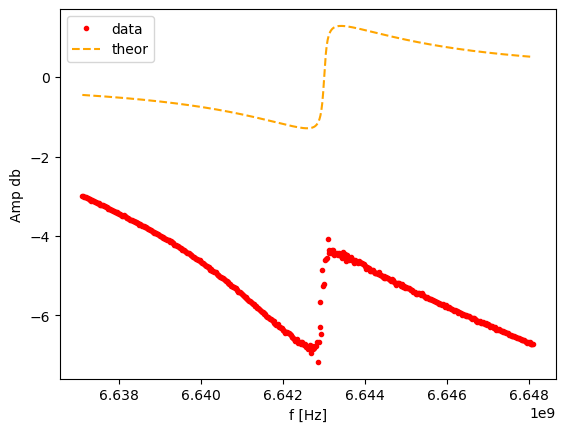

In [1777]:
a, b = 0, len(x1)
omega_data = x1[a: b] 

S_21_data_phase = np.angle(Data[0][a: b]) 

S_21_theor = S21_funcUst_Full(omega_data, omega_r = 6.6430e+09, phi = 0.0000, alpha = 0.0000, a = 0.0030, t = 0.0000, Q_l = 1139.3782, Q_c = 1162.8474) 

S_21_theor_phase = np.angle(S_21_theor) 


plt.plot(omega_data, np.unwrap(S_21_data_phase), '.',label = "data", color = 'red') #abs
plt.plot(omega_data, np.unwrap(S_21_theor_phase) , '--', label = "theor", color = 'orange')


plt.legend()
plt.xlabel('f [Hz]') 
plt.ylabel('Amp db')
plt.show()



### PHASE FIT

In [1782]:
Fit_data_phase = np.angle(Data[0][a: b]) 

def fun(theta):
    theor_curve = S21_funcUst_Full(omega_data, omega_r = theta[0], phi = theta[1], alpha = theta[2], a = theta[3], t = theta[4], Q_l = theta[5], Q_c = theta[6])
    theor_curve = np.angle(theor_curve)
    data_curve = Fit_data_phase 
    return ( np.unwrap(theor_curve) - np.unwrap(data_curve) ) 

theta0 = [6.64298402e+09, 1.00000000e-16, 9.91529023e-16, 3.02710478e-13,
       7.96845425e-15, 1.13937822e+02, 1.56284742e+02] 


# res = sci.least_squares(fun, theta0, bounds=([6.641e9, -2 * np.pi, -2 * np.pi,  0,    0, 1e2, 1e2], 
#                                              [6.643e9,  2 * np.pi,  2 * np.pi, 10, 1e-6, 1e5, 1e5]), verbose = 2)
res = sci.least_squares(fun, theta0, bounds=([6.64e9,      0,      0,  0,     0, 1e2, 1e2], 
                                             [6.65e9,  1e-15,  1e-15,  1, 1e-12, 1e5, 1e5]), verbose = 2)

res.x

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         6.9304e+03                                    1.31e+05    
       1              2         6.4499e+03      4.81e+02       6.36e+06       8.16e+05    
       2              3         3.5311e+03      2.92e+03       1.70e+05       2.63e+03    
       3              4         1.3368e+03      2.19e+03       5.79e+06       7.94e+02    
       4              5         8.9962e+02      4.37e+02       2.76e+06       1.36e+05    
       5              6         5.5491e+02      3.45e+02       3.56e+05       1.06e+04    
       6              7         4.1272e+02      1.42e+02       5.01e+05       8.55e+03    
       7              8         3.8346e+02      2.93e+01       9.84e+04       1.95e+02    
       8             12         3.8345e+02      7.56e-03       3.55e+02       3.26e+00    
       9             13         3.8342e+02      2.99e-02       1.10e+01       1.56e+00    

array([6.64000608e+09, 1.86117875e-23, 6.37774511e-25, 9.99193945e-01,
       9.99999999e-13, 1.60962153e+03, 7.18090513e+02])

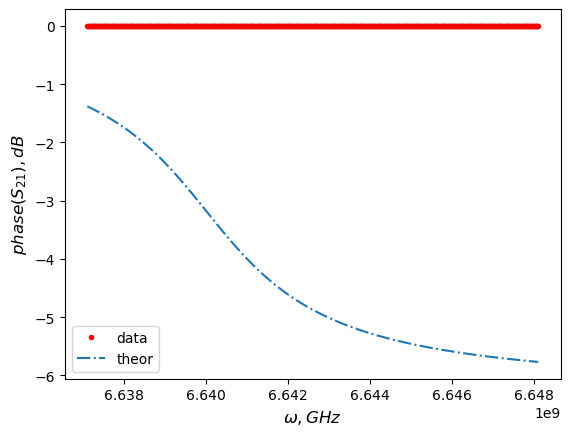

omega_r = 6.6400e+09, phi = 0.0000, alpha = 0.0000, a = 0.9992, t = 0.0000, Q_l = 1609.6215, Q_c = 718.0905


In [1784]:
theor = S21_funcUst_abs_Full(omega_data, omega_r = res.x[0], phi = res.x[1], alpha = res.x[2], a = res.x[3], t = res.x[4], Q_l = res.x[5], Q_c = res.x[6])

theor_phase = np.angle(theor)
plt.plot(omega_data, np.unwrap(Fit_data_abs), '.', label = "data", color = "red")


plt.plot(omega_data, np.unwrap(theor_phase), '-.', label = "theor")
plt.xlabel(r'$\omega, GHz$', fontsize=12)  # Подпись для оси x  
plt.ylabel(r'$phase(S_{21}), dB$', fontsize=12)
plt.legend()
# plt.grid()
# plt.axhline(y = -3)
# plt.axhline(y=-6, color='r', linestyle='--', label='Асимптота x = 0')
# plt.axvline(x = 6.06611010, color='r', linestyle='--', label='Асимптота x = 0')
# plt.savefig('S21_fing_cap_1_ansys.png')
plt.show()
print(f'omega_r = {res.x[0]:.4e}, phi = {res.x[1]:.4f}, alpha = {res.x[2]:.4f}, a = {res.x[3]:.4f}, t = {res.x[4]:.4f}, Q_l = {res.x[5]:.4f}, Q_c = {res.x[6]:.4f}') 

In [1786]:
kappaL = res.x[0]/(res.x[5])
print(f'kappaL = {kappaL:.4e} Hz')

kappaL = 4.1252e+06 Hz


In [1788]:
kappaC = res.x[0]/(res.x[6])
print(f'kappaC = {kappaC:.4e} Hz')

kappaC = 9.2468e+06 Hz


In [1790]:
S21_phi = []
S21_al = []
S21_a = []
S21_t = []

for i in range(100):
    S21_phi.append(S21_funcUst_Full(omega_data, omega_r = 6.6424e+09, phi = (4*np.pi)/100 * i + (- 2 * np.pi), alpha = 0, a = 1, t = 0.0000, Q_l = 1161.8121, Q_c = 1335.1623))
    S21_al.append(S21_funcUst_Full(omega_data, omega_r = 6.6424e+09, phi = 0, alpha = (4*np.pi)/100 * i + (- 2 * np.pi), a = 1, t = 0.0000, Q_l = 1161.8121, Q_c = 1335.1623))
    S21_a.append(S21_funcUst_Full(omega_data, omega_r = 6.6424e+09, phi = 0, alpha = 0, a = (1)/100 * i + (0), t = 0.0000, Q_l = 1161.8121, Q_c = 1335.1623))
    S21_t.append(S21_funcUst_Full(omega_data, omega_r = 6.6424e+09, phi = 0, alpha = 0, a = 1, t = (5e-6)/100 * i + (0), Q_l = 1161.8121, Q_c = 1335.1623))

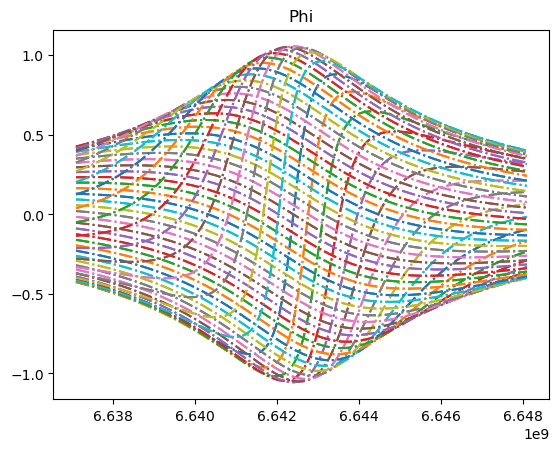

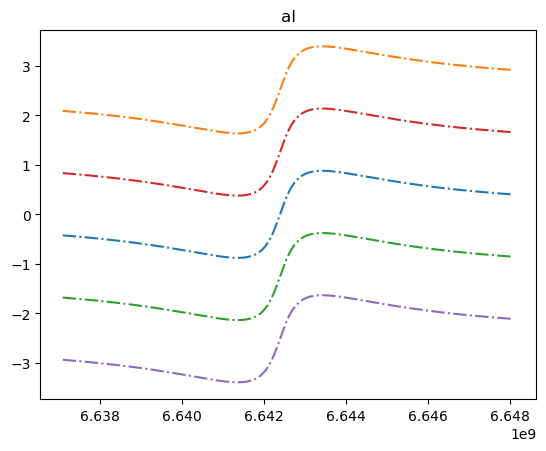

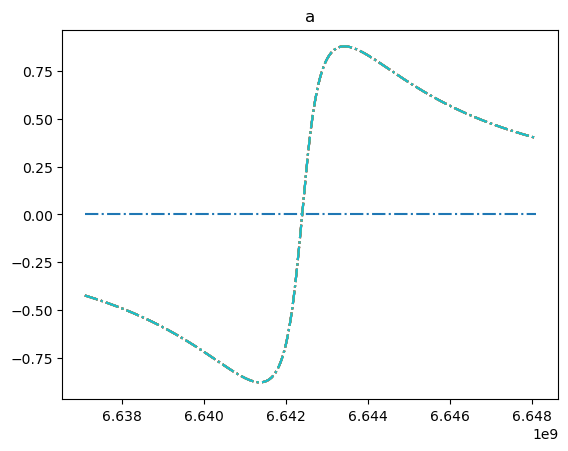

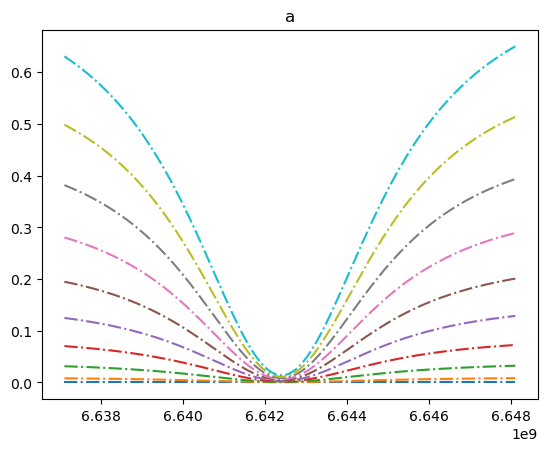

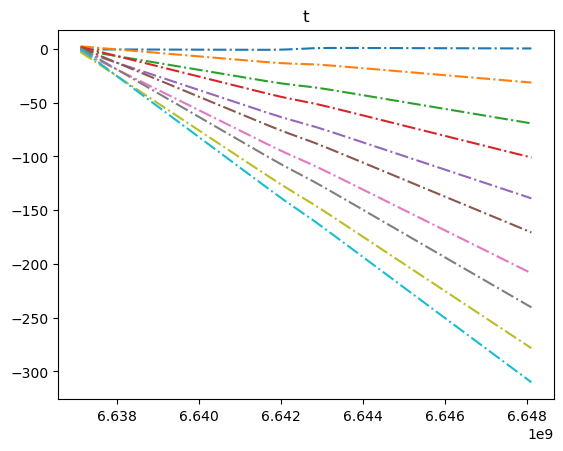

In [1684]:
for i in range(0,100,1):
    plt.plot(omega_data, np.unwrap(np.angle(S21_phi[i])), '-.', label = f"theor")
    plt.title('Phi')
plt.show()

for i in range(0,100,20):
    plt.plot(omega_data, np.unwrap(np.angle(S21_al[i])), '-.', label = f"theor")
    plt.title('al')
plt.show()

for i in range(0,100,10):
    plt.plot(omega_data, np.unwrap(np.angle(S21_a[i])), '-.', label = f"theor")
    plt.title('a')
plt.show()

for i in range(0,100,10):
    plt.plot(omega_data, np.abs(S21_a[i])**2, '-.', label = f"theor")
    plt.title('a')
plt.show()

for i in range(0,100,10):
    plt.plot(omega_data, np.unwrap(np.angle(S21_t[i])), '-.', label = f"theor")
    plt.title('t')
plt.show()



In [1724]:
S21 = Data[0][a: b]

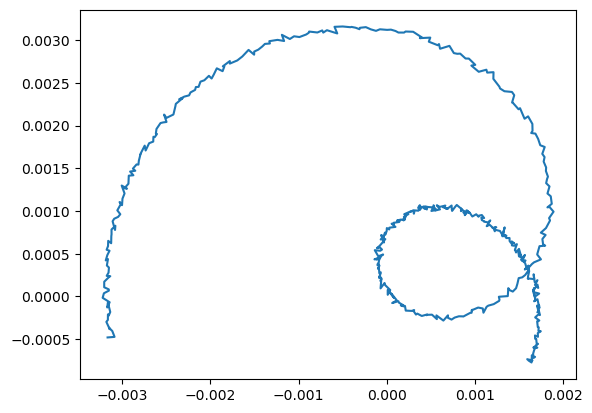

In [1732]:
plt.plot(np.real(S21), np.imag(S21))


# AI TRY

In [1827]:
len(x1)

501

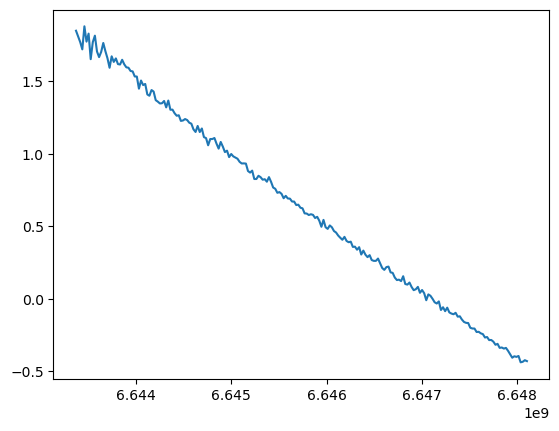

In [2083]:
a, b = 285, 501
Fit_data_phase = np.angle(Data[0][a: b]) 
omega_data = x1[a: b]
plt.plot(omega_data, np.angle(Data[0][a: b]))

In [2089]:
def fun(theta):
    theor_curve = -2 * np.pi * omega_data * theta[0] - theta[1]
    data_curve = Fit_data_phase 
    return ( theor_curve - data_curve) 

theta0 = [7.71674534e-08, 3.22288536e+03] 

norm = sci.least_squares(fun, theta0, bounds=([-np.inf, -np.inf], [np.inf, np.inf]), verbose = 2)
norm.x

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.4872e+09                                    5.81e+16    
       1              2         4.7914e+01      4.49e+09       3.22e+03       1.10e+02    
       2              4         1.2067e+01      3.58e+01       1.61e+03       5.06e+00    
       3              6         3.1057e+00      8.96e+00       8.06e+02       1.21e+00    
       4              8         8.6527e-01      2.24e+00       4.03e+02       1.89e+00    
       5             10         3.0516e-01      5.60e-01       2.01e+02       8.47e-01    
       6             12         1.6513e-01      1.40e-01       1.01e+02       1.92e+00    
       7             14         1.3013e-01      3.50e-02       5.04e+01       1.10e+00    
       8             16         1.2138e-01      8.75e-03       2.52e+01       2.64e+00    
       9             18         1.1919e-01      2.19e-03       1.26e+01       1.15e+00    

array([ 7.71673062e-08, -3.22287921e+03])

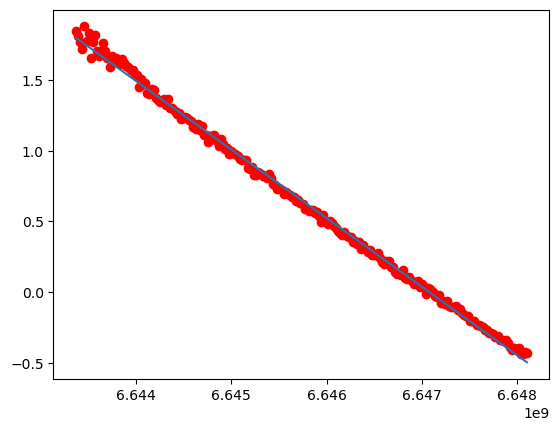

In [2093]:
a = -2 * np.pi * omega_data * norm.x[0] - norm.x[1]
plt.scatter(omega_data, Fit_data_phase, color = 'red')
plt.plot(omega_data, a)


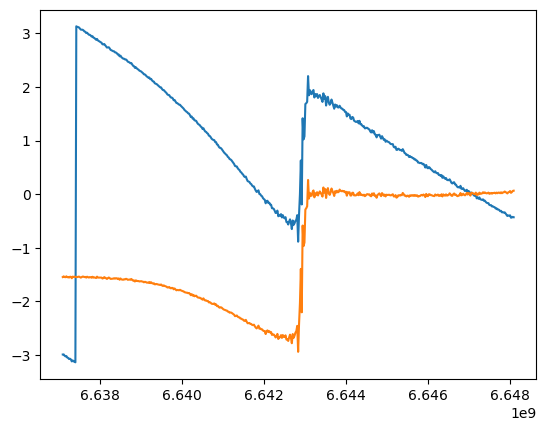

In [2166]:
a, b = 0, len(x1)
omega_data = x1[a: b]
Fit_data_phase = Data[0][a: b] * np.exp(2j * np.pi * omega_data * norm.x[0] + 1j*norm.x[1]) 
Fit_data_phase = np.angle(Fit_data_phase) #+ 2 * np.pi * omega_data * norm.x[0] + norm.x[1]

plt.plot(omega_data, np.angle(Data[0][a: b]))
plt.plot(omega_data, Fit_data_phase)

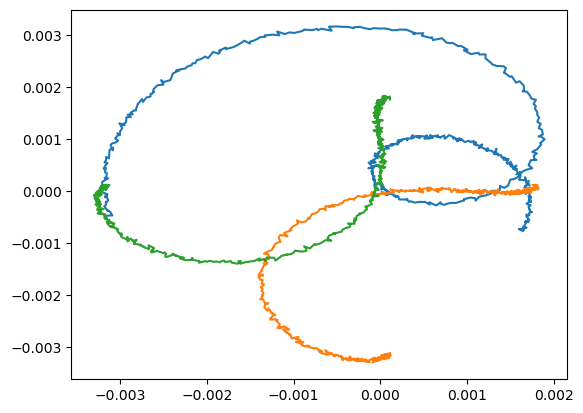

In [2170]:
Fit_data_clear = Data[0][a:b]
S21_Re_clear = np.real(Fit_data_clear)
S21_Im_clear = np.imag(Fit_data_clear)
plt.plot(S21_Re_clear, S21_Im_clear)

Fit_data_phase = Data[0][a:b] * np.exp(2j * np.pi * omega_data * norm.x[0] + 1j*norm.x[1]) # norm.x[1]
S21_Re = np.real(Fit_data_phase)
S21_Im = np.imag(Fit_data_phase)
plt.plot(S21_Re, S21_Im)
plt.plot(S21_Im, S21_Re)

In [2121]:
frequencies = omega_data
S21_data = Data[0][a:b]

In [2136]:
import numpy as np
from scipy.optimize import least_squares

def model_S21(f, a, alpha, tau, fr, Ql, Qc_abs, phi):
    # комплексная модель (notch)
    q_factor = Ql / Qc_abs * np.exp(1j * phi)
    denom = 1 + 2j * Ql * (f / fr - 1)
    S = a * np.exp(1j * alpha) * np.exp(-2j * np.pi * f * tau) * (1 - q_factor / denom)
    return S

def residuals(theta, f, data):
    a, alpha, tau, fr, Ql, Qc_abs, phi = theta
    model = model_S21(f, a, alpha, tau, fr, Ql, Qc_abs, phi)
    return np.concatenate([np.real(model) - np.real(data), np.imag(model) - np.imag(data)])

# Начальные оценки (пример)
theta0 = [0.003, 0.0, 30e-9, 6.64e9, 2000, 2000, 0.0]
bounds_lower = [0.001, -np.pi, 0, 6.63e9, 100, 100, -np.pi]
bounds_upper = [0.01,  np.pi, 100e-9, 6.65e9, 1e6, 1e6,  np.pi]

res = least_squares(residuals, theta0, bounds=(bounds_lower, bounds_upper),
                    args=(frequencies, S21_data))
theta_fit = res.x

In [2138]:
a, alpha, tau, fr, Ql, Qc_abs, phi = theta_fit
model = model_S21(frequencies, a, alpha, tau, fr, Ql, Qc_abs, phi)

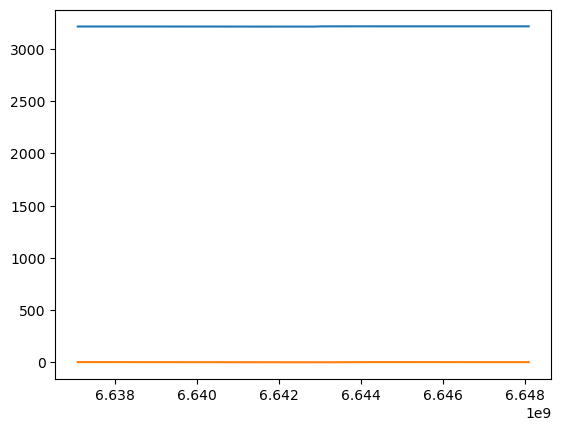

In [2146]:
plt.plot(frequencies, np.unwrap(np.angle(S21_data) + 2*np.pi*frequencies*norm.x[0]))
plt.plot(frequencies, np.unwrap(np.angle(model)))

In [1793]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.linalg import eigh
import matplotlib.pyplot as plt

class ResonatorFitter:
    def __init__(self, freq, S21):
        """
        freq: массив частот в Гц
        S21: комплексный массив S21
        """
        self.freq = np.array(freq)
        self.S21 = np.array(S21)
        self.x = np.real(self.S21)
        self.y = np.imag(self.S21)
        self.params = {}

    def _remove_delay(self):
        """Шаг 1: Удаление задержки кабеля (линейный фит фазы)"""
        phase = np.unwrap(np.angle(self.S21))
        # Фитируем прямую: phase = slope * freq + intercept
        p = np.polyfit(self.freq, phase, 1)
        self.tau = -p[0] / (2 * np.pi)
        
        # Компенсируем задержку
        self.S21_cal = self.S21 * np.exp(1j * 2 * np.pi * self.freq * self.tau)
        self.x_cal = np.real(self.S21_cal)
        self.y_cal = np.imag(self.S21_cal)

    def _algebraic_circle_fit(self):
        """Шаг 2: Алгебраический фит круга (Метод Чернова-Лесора / Проста)"""
        x, y = self.x_cal, self.y_cal
        z = x**2 + y**2
        
        # Матрица моментов M
        M = np.array([
            [np.sum(z**2), np.sum(z*x), np.sum(z*y), np.sum(z)],
            [np.sum(z*x),  np.sum(x**2), np.sum(x*y), np.sum(x)],
            [np.sum(z*y),  np.sum(x*y), np.sum(y**2), np.sum(y)],
            [np.sum(z),    np.sum(x),   np.sum(y),   len(x)]
        ])
        
        # Матрица ограничения B
        B = np.array([
            [0, 0, 0, -2],
            [0, 1, 0, 0],
            [0, 0, 1, 0],
            [-2, 0, 0, 0]
        ])
        
        # Решаем обобщенную задачу на собственные значения: M * v = lambda * B * v
        # Нам нужно наименьшее положительное собственное значение
        eigvals, eigvecs = eigh(M, B)
        
        # Фильтруем положительные собственные значения и берем минимальное
        valid_idx = np.where(eigvals > 0)[0]
        if len(valid_idx) == 0:
            raise ValueError("Не удалось найти круг. Проверьте данные.")
            
        min_idx = valid_idx[np.argmin(eigvals[valid_idx])]
        A_vec = eigvecs[:, min_idx]
        A, B_c, C, D = A_vec
        
        # Нормализуем, чтобы A было положительным (или отрицательным, зависит от реализации)
        # В формуле Проста радиус r0 = 1 / (2 * |A|)
        self.A, self.B_c, self.C, self.D = A, B_c, C, D
        
        # Центр и радиус
        self.xc = -B_c / (2 * A)
        self.yc = -C / (2 * A)
        self.r0 = 1.0 / (2 * np.abs(A))

    def _fit_phase_and_extract(self):
        """Шаг 3 и 4: Фит фазы для поиска fr, Ql и вычисление Qc, Qi"""
        # Переносим круг в начало координат
        S21_trans = self.S21_cal - (self.xc + 1j * self.yc)
        phase_trans = np.unwrap(np.angle(S21_trans))
        
        # Модель фазы
        def phase_model(f, fr, Ql, theta0):
            return theta0 + 2 * np.arctan(2 * Ql * (f / fr - 1))
        
        # Начальные приближения
        fr_guess = self.freq[np.argmax(np.abs(self.S21_cal - (self.xc + 1j*self.yc)))] # Точка diametrically opposite to P
        Ql_guess = fr_guess / (self.freq[-1] - self.freq[0]) * 10 # Грубая оценка
        
        #_bounds для фазы должны быть адекватными!
        bounds = (
            [self.freq.min()*0.9, 10, -2*np.pi], 
            [self.freq.max()*1.1, 1e7, 2*np.pi]
        )
        
        popt, pcov = curve_fit(phase_model, self.freq, phase_trans, 
                               p0=[fr_guess, Ql_guess, 0], bounds=bounds)
        
        self.fr, self.Ql, self.theta0 = popt
        
        # Извлечение параметров окружения и добротностей
        # Угол импедансного рассогласования
        self.phi = -np.arcsin(self.yc / self.r0)
        
        # Комплексная добротность связи
        self.Qc_complex = self.Ql / (2 * self.r0) * np.exp(-1j * self.phi)
        self.Qc = np.abs(self.Qc_complex)
        
        # Внутренняя добротность
        self.Qi = 1.0 / (1.0/self.Ql - np.real(1.0/self.Qc_complex))
        
        # Коэффициенты окружения (a, alpha)
        # Точка вне резонанса P
        beta = (self.theta0 + np.pi) % np.pi - np.pi # Приводим к [-pi, pi]
        P_real = self.xc + self.r0 * np.cos(beta)
        P_imag = self.yc + self.r0 * np.sin(beta)
        self.P = P_real + 1j * P_imag
        
        self.a = np.abs(self.P)
        self.alpha = np.angle(self.P)
        
        self.params = {
            'fr': self.fr,
            'Ql': self.Ql,
            'Qc': self.Qc,
            'Qi': self.Qi,
            'tau': self.tau,
            'a': self.a,
            'alpha': self.alpha,
            'phi': self.phi
        }
        return self.params

    def fit(self):
        """Запуск полного пайплайна"""
        self._remove_delay()
        self._algebraic_circle_fit()
        return self._fit_phase_and_extract()

    def plot_complex(self):
        """Визуализация на комплексной плоскости"""
        plt.figure(figsize=(6,6))
        plt.plot(self.x, self.y, 'b.', label='Raw Data')
        
        # Рисуем фитированный круг
        theta_circle = np.linspace(0, 2*np.pi, 100)
        x_circ = self.xc + self.r0 * np.cos(theta_circle)
        y_circ = self.yc + self.r0 * np.sin(theta_circle)
        plt.plot(x_circ, y_circ, 'r-', label='Algebraic Fit')
        
        plt.plot(self.xc, self.yc, 'kx', label='Center')
        plt.plot(np.real(self.P), np.imag(self.P), 'go', label='Off-resonant P')
        plt.axis('equal')
        plt.grid(True)
        plt.legend()
        plt.xlabel('Re(S21)')
        plt.ylabel('Im(S21)')
        plt.title('Complex Plane Fit')
        plt.show()

In [1795]:
a = ResonatorFitter(omega_data, S21)

In [1817]:
a._remove_delay()
a._algebraic_circle_fit()

LinAlgError: The leading minor of order 1 of B is not positive definite. The factorization of B could not be completed and no eigenvalues or eigenvectors were computed.

# Новый пайплайн фитования S-параметров (Probst / Ustinov)

Ниже — рабочий инструмент, который можно вызывать из этого же ноутбука. Теория разобрана через призму того, **какие параметры в каком порядке фиксировать**, почему старый код расходился, и как независимо проверить результат круговым фитом.

Опорная статья: S. Probst, F. B. Song, P. A. Bushev, A. V. Ustinov, M. Weides, *Efficient and robust analysis of complex scattering data under noise in microwave resonators*, Rev. Sci. Instrum. **86**, 024706 (2015), [arXiv:1410.3365](https://arxiv.org/abs/1410.3365).

Диаметр-коррекция $Q_i$: Khalil et al., J. Appl. Phys. **111**, 054510 (2012). Алгебраический круг: Chernov & Lesort, JMIV **23**, 239 (2005). Сводка методов только по мощности: Petersan & Anlage, J. Appl. Phys. **84**, 3392 (1998). Модель цепи: Gao, PhD Caltech (2008); Pozar, *Microwave Engineering*.


## 1. Что именно мы измеряем

Для планарного резонатора, связанного с линией передачи (notch / hanger / «провал» в $S_{21}$), комплексный коэффициент передачи:

$$
S_{21}(f)= a\, e^{i\alpha}\, e^{-2\pi i f\tau}
\left[
1-\frac{(Q_l/|Q_c|)\,e^{i\varphi}}{1+2i Q_l(f/f_r-1)}
\right]
$$

Две скобки в формуле — это **разные физики**, и их нельзя фитить одним комком без иерархии.

| Символ | Смысл | Где живёт в данных |
|---|---|---|
| $f_r$ | резонанс | центр круга по частоте / точка, диаметрально противоположная off-resonant $P$ |
| $Q_l$ | loaded / total Q | скорость обхода круга, FWHM $=f_r/Q_l$ |
| $|Q_c|$ | связь с линией | диаметр круга $d=Q_l/|Q_c|$ |
| $\varphi$ | импедансный mismatch (Fano) | поворот круга вокруг $P$; асимметрия $|S_{21}|$ |
| $a$ | усиление/ослабление тракта | радиус «большого» масштаба, baseline |
| $\alpha$ | постоянный фазовый сдвиг | поворот всей картины |
| $\tau$ | электрическая задержка кабеля | линейный наклон фазы, петля вместо круга |

DCM (Khalil): $Q_c=|Q_c|e^{-i\varphi}$, затем

$$
Q_i^{-1}=Q_l^{-1}-\mathrm{Re}(Q_c^{-1})=Q_l^{-1}-\cos\varphi/|Q_c|.
$$

Без $\mathrm{Re}$ (просто $Q_i^{-1}=Q_l^{-1}-|Q_c|^{-1}$) $Q_i$ **систематически завышается** при $\varphi\neq 0$.


## 2. Почему старый код не сходился (разбор вашего файла)

Это не «плохо подобран стартовый вектор», а несколько независимых ошибок модели и residuals.

1. **Перепутаны $a$ и $\alpha$.** В Probst $a$ — амплитуда, $\alpha$ — фаза. В `S21_funcUst_abs_Full` было `alpha * exp(1j*a)`. Тогда фиттер раздувает «фазу» до $10^5$ и «задержку» до $10^6$ с, чтобы компенсировать.

2. **Неверная нормализация фазы.** Нужно
   `S * np.exp(2j * np.pi * f * tau)`,
   то есть $+2\pi i f\tau$, если модель содержит $e^{-2\pi i f\tau}$.
   Запись `exp(2*pi**i*f*tau)` — это $\pi^{i}$, а не мнимая единица. Отсюда «отрезал delay — круг не стал кругом».

3. **Линейный фит всей фазы, включая резонанс.** Скачок $\arctan$ на $\sim 2\pi$ ломает оценку $\tau$. Сначала выкидываем $\pm$ несколько FWHM вокруг дипа, потом уточняем $\tau$ по крутизне «насколько locus круглый» (Probst §III).

4. **`np.unwrap(model) - np.unwrap(data)`.** Unwrap модели и данных прыгает независимо. Residual по фазе должен быть круговым: `np.angle(exp(1j*(φ_m-φ_d)))`.

5. **Границы, убивающие физику.** В «New FIT» стояло `phi, alpha ∈ [0, 1e-12]`. Fano и стартовая фаза были запрещены — асимметрия уходила в ложные $Q$.

6. **Амплитуда: $|S|^2$ vs dB vs линейный $|S|$.** Модель иногда возвращала $|S|^2$, данные были в dB, вычитание шло «в лоб». Плюс $|S|^2$ перевешивает baseline и недовешивает дно дипа.

7. **$Q=f/(2\kappa)$. ** Если $\kappa$ — FWHM в герцах, то $Q=f/\kappa$. Лишняя двойка даёт вдвое меньшую добротность (у вас в комментариях Q≈1377 при FWHM≈2.08 MHz на 5.73 GHz; правильный порядок $Q_l\approx 2750$). Двойка появляется только если $\kappa$ — HWHM или если путают $\omega$ и $f$.

8. **Circle fit в `ResonatorFitter`.** `r0=1/(2|A|)` верно **только после** нормировки собственного вектора на связь $B^2+C^2-4AD=1`. `eigh(M,B)` этого не гарантирует, $B$ не положительно определена. Формула фазы у Probst: $\theta=\theta_0+2\arctan[2Q_l(1-f/f_r)]$ (знак $(1-f/f_r)$, не наоборот, если $\theta_0$ согласован).

9. **Последовательность «сначала фаза → подставить в амплитуду». ** Сырая фаза на 90% — это $-2\pi f\tau$. $Q$ из такой фазы неустойчив, и $|S|$ от $\tau,\alpha$ не зависит, поэтому «идеального наложения» не будет, пока delay не снят.


## 3. Какие параметры трогать в каком порядке

Идентифицируемость (что реально видно в данных):

| Данные | Надёжно | Осторожно | Нельзя |
|---|---|---|---|
| полный комплексный $S_{21}$ (notch) | $f_r,Q_l,\|Q_c\|,\varphi,a,\alpha,\tau$ → $Q_i$ по DCM | $Q_i$ при SNR≲20 или span≲2 FWHM | — |
| только $\|S_{21}\|$ (notch) | $f_r,Q_l,a$ (baseline), $\varphi$ (асимметрия), $\|Q_c\|$ (глубина) | $Q_i$ (через DCM, хуже ошибок) | $\tau,\alpha$ |
| только $\|S_{21}\|$ (through / пик) | $f_r,Q_l$, амплитуда пика $a Q_l/\|Q_c\|$ | $\varphi$ | раздельно $a$ и $Q_c$, значит $Q_i$ |
| только фаза | $\tau,\alpha,f_r,Q_l$ | $\varphi,\|Q_c\|$ (глубина фазового скачка) | $a$ |

Практический порядок (оба инструмента ниже так и делают):

1. Вырезать окно $\sim 4$–$10$ ширины $f_r/Q_l$ (Probst: примерно 4× 3 dB BW, ≥200 точек на высоком SNR для калибровки тракта).
2. Оценить $\tau$ по **off-resonance** фазе, уточнить алгебраическим кругом.
3. Снять delay: $S\leftarrow S\,e^{+2\pi i f\tau}$. Locus обязан стать дугой/кругом, не петлёй.
4. **Амплитуда:** $\{a,f_r,Q_l,\|Q_c\|,\varphi\}$. Не трогать $\tau,\alpha$.
5. **Фаза:** сначала $\{\alpha,\tau\}$ при замороженных $Q$, потом отпустить $f_r,Q_l,\varphi$.
6. Комплексный polish всех семи параметров (Re/Im residual, не $|S|$).
7. Независимый **circle fit** на тех же delay-corrected данных. Если $f_r$ и $Q_l$ совпали — анализ достоверный. Если нет — смотреть span, второй резонанс, baseline.


## 4. Два главных инструмента

**A. `fit_amp_phase`** — амплитуда → фаза → комплексный polish.  
**B. `fit_circle`** — алгебраический круг Chernov–Lesort + фаза $\theta(f)$ + DCM, затем polish.

`fit_hybrid` запускает оба и сравнивает RMS. `fit_magnitude_only` — когда фазы нет.

Код лежит в пакете `sparam_fit` рядом с репозиторием. Ниже — самодостаточный вызов на синтетике (ваши `.exdir`/CSV с Windows-путей в этой среде нет). На своих данных:

```python
from sparam_fit import fit_amp_phase, fit_circle, fit_hybrid, fit_magnitude_only
best, r_ap, r_c = fit_hybrid(freq_hz, s21_complex, geometry="notch")
print(best.summary())
```

`geometry="notch"` для hanger / flip-chip readout line. Для through-резонатора (пик) — `"transmission"` (тогда $Q_i$ из одного $S_{21}$ без калибровки $a$ не отделяется).


In [ ]:
import sys
from pathlib import Path
root = Path.cwd()
for cand in [root, root.parent, Path('/workspace')]:
    if (cand / 'sparam_fit').is_dir():
        sys.path.insert(0, str(cand))
        break

import numpy as np
import matplotlib.pyplot as plt
from sparam_fit import fit_amp_phase, fit_circle, fit_hybrid, fit_magnitude_only
from sparam_fit.models import ResonatorParams, model_s
from sparam_fit.synthetic import make_trace
from sparam_fit.plots import plot_fit_report, plot_delay_before_after
from sparam_fit.guess import guess_delay_linear, refine_delay_circle, remove_delay

true = ResonatorParams(
    fr=6.642e9, Ql=1160.0, absQc=1550.0, phi=0.18,
    a=0.0032, alpha=-0.9, tau=38e-9, geometry='notch',
)
f, s = make_trace(true, n=601, span_bw=10.0, snr=70, seed=11)
print('synthetic points', len(f), 'span', f[-1]-f[0], 'Hz')


### Шаг delay: почему `S * exp(2π i f τ)`, а не линейный фит всей фазы

Кабель даёт $e^{-2\pi i f\tau}$. Компенсация — умножение на сопряжённый фазовый фактор. Если $\tau$ угадан, Im vs Re становится окружностью (не «улиткой»).


In [ ]:
tau0, fr_g, Ql_g = guess_delay_linear(f, s)
tau = refine_delay_circle(f, s, tau0)
print(f'linear tau={tau0:.6e} s,  refined={tau:.6e} s,  true={true.tau:.6e} s')
plot_delay_before_after(f, s, tau)
plt.show()


### Инструмент 1 — амплитуда и фаза

Порядок внутри `fit_amp_phase`: $|S|$ (без $\tau,\alpha$) → фаза среды → фаза резонатора → Re/Im polish.


In [ ]:
r_ap = fit_amp_phase(f, s, geometry='notch')
print(r_ap.summary())
plot_fit_report(f, s, r_ap, title='amp + phase')
plt.show()


### Инструмент 2 — круговой фит

Алгебраический круг не требует стартовых $x_c,y_c,r$. Диаметр $d=2r_0$ на каноническом круге даёт $|Q_c|=Q_l/d$. Это независимая проверка шага 1: те же $f_r,Q_l,Q_i$ должны совпасть.


In [ ]:
r_c = fit_circle(f, s, geometry='notch')
print(r_c.summary())
plot_fit_report(f, s, r_c, title='circle fit')
plt.show()
print('Δfr / fr =', abs(r_ap.params.fr - r_c.params.fr)/true.fr)
print('ΔQl / Ql =', abs(r_ap.params.Ql - r_c.params.Ql)/true.Ql)
print('ΔQi / Qi =', abs(r_ap.params.Qi_dia_corr - r_c.params.Qi_dia_corr)/true.Qi_dia_corr)


### Только амплитуда

Если фазы нет (Ansys часто отдаёт только dB): `fit_magnitude_only`. $f_r$ и $Q_l$ остаются хорошими; $\tau,\alpha$ нули; $Q_i$ — оценка с оговоркой.


In [ ]:
r_m = fit_magnitude_only(f, np.abs(s), geometry='notch')
print(r_m.summary())


### Гибрид и как фитить ваши реальные следы

Если в ноутбуке уже есть `x1` и `Data[0]` (комплексный $S_{21}$), раскомментируйте блок. Окно `a:b` должно покрывать **один** резонанс, не весь чип.


In [ ]:
# --- реальные данные из ячеек выше (раскомментировать у себя) ---
# freq = np.asarray(x1[a:b], dtype=float)
# s21 = np.asarray(Data[0][a:b], dtype=np.complex128)
# best, r_ap, r_c = fit_hybrid(freq, s21, geometry='notch')
# print(best.summary())
# plot_fit_report(freq, s21, r_ap, title='amp+phase on experiment')
# plot_fit_report(freq, s21, r_c, title='circle on experiment')

best, r_ap, r_c = fit_hybrid(f, s, geometry='notch')
print(best.summary())
print('cross-check ΔQi =', best.diagnostics['delta_Qi'])


## 5. Как читать достоверность

- Согласие circle vs amp+phase по $f_r$ лучше $10^{-5}$ относительных и по $Q_l$ лучше пары процентов — норма для SNR≳50.
- Если круговой фит круглый, а $|S|$ фитится криво — виноват baseline / второй мод / неверный `geometry`.
- Если $|S|$ хорош, а круг — спираль, не снят $\tau$ или $\tau$ частотно-зависимый на широком span.
- $Q_i$ всегда шумнее $Q_l$: это *разность* двух близких чисел. DCM обязателен при видимой асимметрии.
- Калибровку тракта $(a,\alpha,\tau)$ Probst советует один раз на высоком SNR, дальше фитить уже 4 параметра резонатора. В `fit_circle` / `fit_amp_phase` это можно имитировать, передав известный `tau=...`.
